# Monthly Stock Return Prediction Under Market Regimes

**Project Structure:**
1. Data Loading & Feature Engineering
2. Market Regime Detection (HMM)
3. Helper Functions & Model Builders
4. Monthly Dataset Assembly & Feature Diagnostics
5. Baseline Models (LightGBM on Cleaner Feature Sets)
6. Model Family Comparison (LightGBM vs XGBoost vs LSTM)
7. Report Charts, LSTM Tuning & Regime-Aware Extension
8. Model Diagnostics & Feature Importance
9. Fama-MacBeth Extension (Optional)
10. Conclusion

# 1. Data Loading & Feature Engineering

In [8]:
import kagglehub
import yfinance as yf
import numpy as np
import pandas as pd
from pathlib import Path
from hmmlearn import hmm
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# ========== Configuration ==========
BASE_PATH = Path("/Users/wantwa/.cache/kagglehub/datasets/mohammedobeidat/us-stock-market-data/versions/2")
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JNJ', 'XOM', 'V', 'WMT', 'NVDA', 'PG',
           'LLY', 'CVX', 'MA', 'HD', 'PFE', 'MRK', 'KO', 'PEP', 'ORCL',
           'TMO', 'AZN', 'CSCO', 'DHR', 'MCD', 'ABT', 'TMUS', 'ACN', 'NEE', 'VZ', 'TTE',
           'LIN', 'DIS', 'PM', 'BMY', 'CMCSA', 'SCHW', 'UPS', 'TXN', 'RTX', 'COP']

FORECAST_HORIZON = 21   # Future 21 trading days (1 month)
FUND_LAG_MONTHS = 3     # Fundamental lag: 3 months for one quarter

# ========== Data Loading ==========
def load_single_stock(ticker, base_path, data_type="train"):
    tech_path = base_path / "technials" / data_type / f"{ticker}_technicals_{data_type}.csv"
    tech_df = pd.read_csv(tech_path, parse_dates=['Date'])
    tech_df['ticker'] = ticker
    tech_df.set_index('Date', inplace=True)

    fund_path = base_path / "fundamentals" / data_type / f"{ticker}_fundamentals_{data_type}.csv"
    fund_df = pd.read_csv(fund_path, parse_dates=['Date'])
    fund_df['ticker'] = ticker
    fund_df.set_index('Date', inplace=True)

    merged = tech_df.join(fund_df, how='left', rsuffix='_fund')
    merged.drop(columns=['ticker_fund'], inplace=True, errors='ignore')
    merged.reset_index(inplace=True)
    return merged

def build_panel_dataset(tickers, base_path, data_type="train"):
    all_dfs = []
    for ticker in tickers:
        try:
            df = load_single_stock(ticker, base_path, data_type)
            all_dfs.append(df)
            print(f"✓ {ticker}")
        except Exception as e:
            print(f"✗ {ticker}: {e}")
    panel = pd.concat(all_dfs, ignore_index=True)
    panel = panel.sort_values(['Date', 'ticker']).reset_index(drop=True)
    return panel

# ========== Feature Engineering ==========
def lag_fundamentals(panel, lag_months=3):
    fund_cols = ['pe_ratio', 'pb_ratio', 'ps_ratio', 'pfcf_ratio',
                 'return_on_equity', 'return_on_assets', 'debt_to_equity_ratio',
                 'current_ratio', 'ebitda', 'revenue']
    available_fund_cols = [c for c in fund_cols if c in panel.columns]

    def shift_group(df_group):
        df_group = df_group.sort_values('Date')
        for col in available_fund_cols:
            df_group[col] = df_group[col].shift(lag_months * 30)
        return df_group

    panel = panel.groupby('ticker', group_keys=False).apply(shift_group)
    return panel

def compute_features(panel):
    panel = panel.sort_values(['ticker', 'Date']).copy()
    panel['return_1m'] = panel.groupby('ticker')['close'].pct_change(periods=21)
    panel['return_3m'] = panel.groupby('ticker')['close'].pct_change(periods=63)
    panel['momentum_12m'] = panel.groupby('ticker')['close'].pct_change(periods=252)
    panel['sma_50_sma_200_ratio'] = panel['sma_50-sma_200_rate']
    panel['MACDh'] = panel['MACDh_10_26_9']
    panel['volatility_1m'] = panel['stdev']
    panel['ATR'] = panel['atr']
    panel['log_volume'] = np.log1p(panel['volume'])
    panel['obv'] = panel['obv']
    panel['pe_ratio'] = panel['pe_ratio']
    panel['pb_ratio'] = panel['pb_ratio']
    panel['ps_ratio'] = panel['ps_ratio']
    panel['pfcf_ratio'] = panel['pfcf_ratio']
    panel['return_on_equity'] = panel['return_on_equity']
    panel['return_on_assets'] = panel['return_on_assets']
    panel['debt_to_equity'] = panel['debt_to_equity_ratio']
    panel['current_ratio'] = panel['current_ratio']
    panel['ebitda_margin'] = panel['ebitda'] / panel['revenue']
    return panel

def generate_regression_target(panel, horizon=21):
    panel = panel.sort_values(['ticker', 'Date']).copy()
    panel['future_return'] = panel.groupby('ticker')['close'].pct_change(periods=horizon).shift(-horizon)
    return panel

def handle_missing(panel, feature_cols):
    panel = panel.sort_values(['ticker', 'Date']).copy()
    panel[feature_cols] = panel.groupby('ticker')[feature_cols].ffill()
    panel = panel.dropna(subset=feature_cols + ['future_return']).reset_index(drop=True)
    return panel

# ========== Feature column list ==========
feature_cols = [
    'return_1m', 'return_3m', 'momentum_12m', 'sma_50_sma_200_ratio',
    'MACDh', 'volatility_1m', 'ATR', 'log_volume', 'obv',
    'pe_ratio', 'pb_ratio', 'ps_ratio', 'pfcf_ratio',
    'return_on_equity', 'return_on_assets', 'ebitda_margin',
    'debt_to_equity', 'current_ratio'
]

In [9]:
# Build panel datasets
print("Building train data...")
train_raw = build_panel_dataset(TICKERS, BASE_PATH, "train")
print(f"Raw training set shape: {train_raw.shape}")

print("Building test data...")
test_raw = build_panel_dataset(TICKERS, BASE_PATH, "test")
print(f"Raw testing set shape: {test_raw.shape}")

# Fundamental lag (avoid data leakage)
print("Processing fundamental lag...")
train_raw = lag_fundamentals(train_raw, lag_months=FUND_LAG_MONTHS)
test_raw = lag_fundamentals(test_raw, lag_months=FUND_LAG_MONTHS)

# Feature engineering
print("Computing features...")
train_df = compute_features(train_raw)
test_df = compute_features(test_raw)

# Regression target
print("Generating forecast target...")
train_df = generate_regression_target(train_df, horizon=FORECAST_HORIZON)
test_df = generate_regression_target(test_df, horizon=FORECAST_HORIZON)

# Ensure all feature columns exist
missing_features = [f for f in feature_cols if f not in train_df.columns]
if missing_features:
    print(f"Warning: missing features {missing_features}")
    for f in missing_features:
        train_df[f] = np.nan
        test_df[f] = np.nan

# Handle missing values
print("Processing missing values...")
train_df = handle_missing(train_df, feature_cols)
test_df = handle_missing(test_df, feature_cols)

# Save
train_df.to_csv("train_final.csv", index=False)
test_df.to_csv("test_final.csv", index=False)

print(f"Final training samples: {len(train_df)}")
print(f"Final testing samples: {len(test_df)}")

Building train data...
✓ AAPL
✓ MSFT
✓ GOOGL
✓ AMZN
✓ JNJ
✓ XOM
✓ V
✓ WMT
✓ NVDA
✓ PG
✓ LLY
✓ CVX
✓ MA
✓ HD
✓ PFE
✓ MRK
✓ KO
✓ PEP
✓ ORCL
✓ TMO
✓ AZN
✓ CSCO
✓ DHR
✓ MCD
✓ ABT
✓ TMUS
✓ ACN
✓ NEE
✓ VZ
✓ TTE
✓ LIN
✓ DIS
✓ PM
✓ BMY
✓ CMCSA
✓ SCHW
✓ UPS
✓ TXN
✓ RTX
✓ COP
Raw training set shape: (100320, 86)
Building test data...
✓ AAPL
✓ MSFT
✓ GOOGL
✓ AMZN
✓ JNJ
✓ XOM
✓ V
✓ WMT
✓ NVDA
✓ PG
✓ LLY
✓ CVX
✓ MA
✓ HD
✓ PFE
✓ MRK
✓ KO
✓ PEP
✓ ORCL
✓ TMO
✓ AZN
✓ CSCO
✓ DHR
✓ MCD
✓ ABT
✓ TMUS
✓ ACN
✓ NEE
✓ VZ
✓ TTE
✓ LIN
✓ DIS
✓ PM
✓ BMY
✓ CMCSA
✓ SCHW
✓ UPS
✓ TXN
✓ RTX
✓ COP
Raw testing set shape: (25120, 86)
Processing fundamental lag...
Computing features...
Generating forecast target...
Processing missing values...
Final training samples: 89400
Final testing samples: 14200


# 2. Market Regime Detection (HMM)

Use a 2-state Gaussian HMM on market-level features (NASDAQ-100 log returns, 20-day volatility, VIX level, and VIX change) to classify each trading day as bull or bear.

Model is not converging.  Current: 21109.70889766775 is not greater than 21109.758451114776. Delta is -0.04955344702466391
Model is not converging.  Current: 21109.726596103836 is not greater than 21109.758902261998. Delta is -0.03230615816210047
Model is not converging.  Current: 21109.652500545584 is not greater than 21109.683194271645. Delta is -0.030693726061144844
Model is not converging.  Current: 21109.700926645775 is not greater than 21109.75631629201. Delta is -0.05538964623337961
Model is not converging.  Current: 21109.745516815972 is not greater than 21109.767318692444. Delta is -0.021801876471727155
Model is not converging.  Current: 21109.720976651824 is not greater than 21109.756767578023. Delta is -0.03579092619838775
Model is not converging.  Current: 21109.68873827385 is not greater than 21109.737351121552. Delta is -0.048612847702315776
Model is not converging.  Current: 21109.716519046517 is not greater than 21109.764366444066. Delta is -0.047847397549048765
Model i

State characteristics:
        returns           volatility                  vix            \
           mean       std       mean       std       mean       std   
state                                                                 
0      0.000034  0.019093   0.017699  0.006958  27.279373  7.909272   
1      0.001032  0.008252   0.008284  0.002507  15.005821  2.894207   

      vix_change            
            mean       std  
state                       
0       0.000073  0.090466  
1      -0.000368  0.068316  

State distribution:
state
1    2228
0    1276
Name: count, dtype: int64


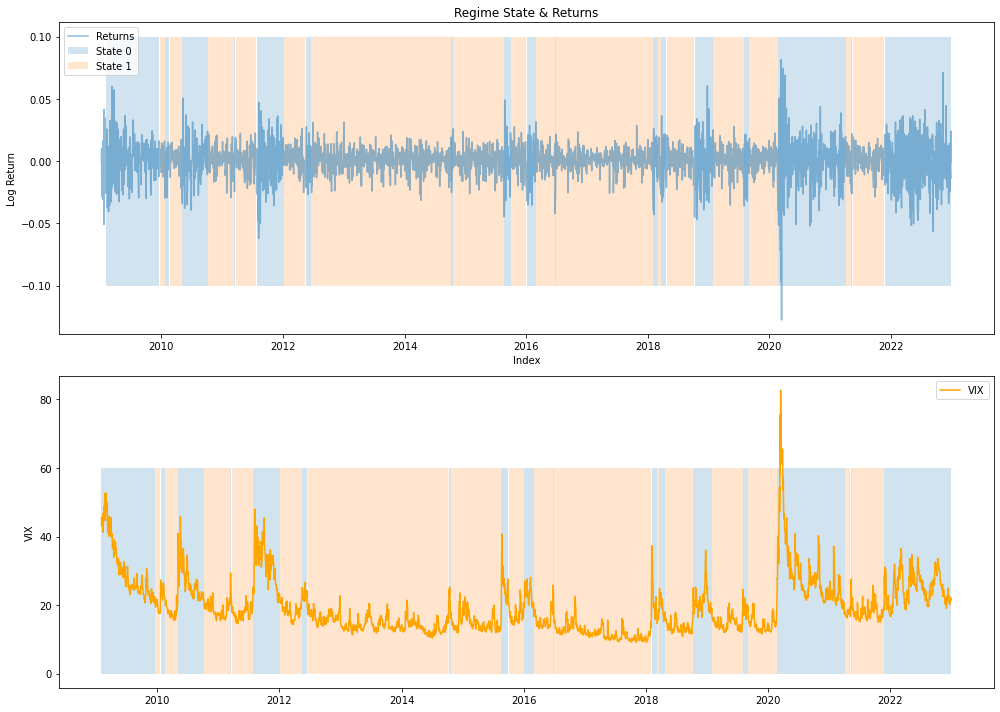

In [10]:
# NASDAQ-100 ETF prices
prices = pd.read_csv('/Users/wantwa/SDSC4009/nasdaq100.csv').set_index('Date')

# VIX prices
vix_prices = pd.read_csv('/Users/wantwa/SDSC4009/vixprices.csv').set_index('Date')

# Market-level features
returns = np.log(prices / prices.shift(1)).dropna()
volatility = returns.rolling(window=20).std().dropna()
returns.rename(columns={'QQQ': 'returns'}, inplace=True)
volatility.rename(columns={'QQQ': 'volatility'}, inplace=True)

vix_change = np.log(vix_prices / vix_prices.shift(1))
vix_change.rename(columns={'^VIX': 'vix_change'}, inplace=True)
vix_prices.rename(columns={'^VIX': 'vix'}, inplace=True)

features = pd.concat([returns, volatility, vix_prices, vix_change], axis=1).dropna()

# Fit HMM with multiple restarts for stability
def get_stable_hmm(features, n_components=2, n_trials=20):
    best_model = None
    best_score = -np.inf
    for seed in range(n_trials):
        model = hmm.GaussianHMM(n_components=n_components,
                                covariance_type="full",
                                n_iter=1000,
                                random_state=seed,
                                verbose=False)
        model.fit(features.values)
        score = model.score(features.values)
        if score > best_score:
            best_score = score
            best_model = model
    return best_model

best_hmm = get_stable_hmm(features, n_components=2)
states = best_hmm.predict(features.values)
features['state'] = states

# State characteristics
state_means = features.groupby('state').agg(['mean', 'std'])
print("State characteristics:")
print(state_means)
print('\nState distribution:')
print(features['state'].value_counts())

idx = pd.to_datetime(returns.index)
# Visualization
fig, ax = plt.subplots(2, 1, figsize=(14, 10))
ax[0].plot(idx, returns, label='Returns', alpha=0.5)
ax[0].set_title('Regime State & Returns')
ax[0].set_xlabel('Index')
ax[0].set_ylabel('Log Return')
ax[1].plot(pd.to_datetime(features.index), features['vix'], label='VIX', color='orange')
ax[1].set_ylabel('VIX')

for state in [0, 1]:
    mask = features['state'] == state
    ax[0].fill_between(pd.to_datetime(features.index), -0.1, 0.1, where=mask, alpha=0.2, label=f'State {state}')
    ax[1].fill_between(pd.to_datetime(features.index), 0, 60, where=mask, alpha=0.2)

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

# Extract regime series for later merging
regime_df = features['state']
regime_df.index = pd.to_datetime(regime_df.index)

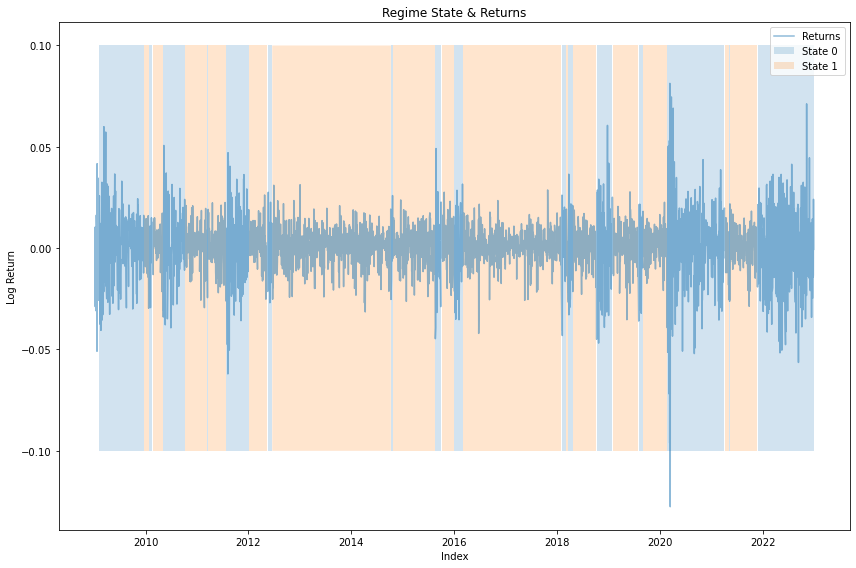

In [11]:
plt.figure(figsize=(12, 8))
plt.plot(idx, returns, label='Returns', alpha=0.5)
plt.title('Regime State & Returns')
plt.xlabel('Index')
plt.ylabel('Log Return')

for state in [0, 1]:
    mask = features['state'] == state
    plt.fill_between(pd.to_datetime(features.index), -0.1, 0.1, where=mask, alpha=0.2, label=f'State {state}')

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Generally
# high returns(0.001032) & low vol(0.008284)  -- bull market         --- state 1 (orange)
# low/negative returns(0.000034) & high vol(0.017699) -- bear market --- state 0 (blue)

# 3. Helper Functions & Model Builders

Evaluation metrics, monthly panel construction, cross-sectional quantile transform, LightGBM/XGBoost builders, regime-aware framework, feature diagnostics, feature importance, and Fama-MacBeth.

In [13]:
import subprocess, sys
from textwrap import fill

try:
    import lightgbm as lgb
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm'])
    import lightgbm as lgb

try:
    import xgboost as xgb
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])
    import xgboost as xgb

import statsmodels.api as sm
from IPython.display import display
from scipy.stats import t as student_t
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ========== Evaluation ==========
def compute_r2_oos(y_true, y_pred, benchmark_mean):
    benchmark_pred = np.full(len(y_true), benchmark_mean, dtype=float)
    numerator = np.sum((np.asarray(y_true) - np.asarray(y_pred)) ** 2)
    denominator = np.sum((np.asarray(y_true) - benchmark_pred) ** 2)
    if denominator == 0:
        return np.nan
    return 1 - numerator / denominator

def evaluate_regression_metrics_monthly(y_true, y_pred, benchmark_mean=None):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    r2_oos = compute_r2_oos(y_true, y_pred, benchmark_mean) if benchmark_mean is not None else np.nan
    ic = spearmanr(y_true, y_pred)[0]
    if np.isnan(ic):
        ic = 0.0
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2, 'r2_oos': r2_oos, 'ic': ic}

# ========== Monthly Panel Construction ==========
def build_month_end_panel(panel, regime_series, feature_cols):
    panel = panel.copy()
    if 'Date' not in panel.columns:
        panel = panel.reset_index()
    panel['Date'] = pd.to_datetime(panel['Date'])
    panel = panel.sort_values(['ticker', 'Date'])

    regime_lookup = regime_series.rename('state').rename_axis('Date').reset_index()
    regime_lookup['Date'] = pd.to_datetime(regime_lookup['Date'])
    panel = panel.merge(regime_lookup, on='Date', how='inner')

    panel['month'] = panel['Date'].dt.to_period('M')
    month_end = panel.groupby(['ticker', 'month'], as_index=False).tail(1).copy()
    month_end = month_end.sort_values(['ticker', 'Date'])
    month_end['future_return_1m'] = month_end.groupby('ticker')['close'].shift(-1) / month_end['close'] - 1
    month_end = month_end.dropna(subset=feature_cols + ['future_return_1m']).reset_index(drop=True)
    return month_end

def cross_sectional_quantile_transform(panel, feature_cols, suffix='_cs_q'):
    panel = panel.copy()
    transformed_groups = []
    for _, df in panel.groupby('Date', sort=False):
        df = df.copy()
        for col in feature_cols:
            ranks = df[col].rank(method='average', pct=True)
            if ranks.nunique() <= 1:
                df[f'{col}{suffix}'] = 0.0
            else:
                df[f'{col}{suffix}'] = (ranks - 0.5) * 2
        transformed_groups.append(df)
    transformed = pd.concat(transformed_groups, ignore_index=True)
    transformed_cols = [f'{col}{suffix}' for col in feature_cols]
    return transformed, transformed_cols

def map_raw_to_cs_features(raw_feature_cols, suffix='_cs_q'):
    return [f'{col}{suffix}' for col in raw_feature_cols]

# ========== LightGBM ==========
def get_lightgbm_params(objective='regression'):
    return {
        'objective': objective, 'n_estimators': 300, 'learning_rate': 0.03,
        'num_leaves': 31, 'min_child_samples': 10, 'subsample': 0.8,
        'colsample_bytree': 0.8, 'random_state': 42, 'verbosity': -1
    }

def build_lightgbm_model(objective='regression'):
    return lgb.LGBMRegressor(**get_lightgbm_params(objective=objective))

# ========== XGBoost ==========
def build_xgboost_model():
    return xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=42, objective='reg:squarederror', verbosity=0
    )

# ========== Time-Series CV ==========
def time_series_cv_eval_model_by_date(X, y, build_model, n_splits=3, test_size=6):
    date_index = pd.Index(pd.to_datetime(X.index), name='Date')
    unique_dates = pd.Index(sorted(date_index.unique()))
    if len(unique_dates) <= n_splits * test_size:
        raise ValueError(f'Not enough unique dates for CV: got {len(unique_dates)} dates.')

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    fold_metrics = []

    for fold, (train_date_idx, val_date_idx) in enumerate(tscv.split(unique_dates), start=1):
        train_dates = unique_dates[train_date_idx]
        val_dates = unique_dates[val_date_idx]
        train_mask = date_index.isin(train_dates)
        val_mask = date_index.isin(val_dates)
        y_train_fold = y.loc[train_mask]
        model = build_model()
        model.fit(X.loc[train_mask], y_train_fold)
        y_pred = model.predict(X.loc[val_mask])
        metrics = evaluate_regression_metrics_monthly(y.loc[val_mask], y_pred, benchmark_mean=y_train_fold.mean())
        fold_metrics.append(metrics)
        print(f"Fold {fold}: train {train_dates.min().date()} -> {train_dates.max().date()} ({train_mask.sum()} rows), "
              f"val {val_dates.min().date()} -> {val_dates.max().date()} ({val_mask.sum()} rows), "
              f"MSE = {metrics['mse']:.6f}, IC = {metrics['ic']:.4f}")

    summary = pd.DataFrame(fold_metrics).mean().to_dict()
    print(f"Average MSE: {summary['mse']:.6f}, Average IC: {summary['ic']:.4f}")
    return summary

# ========== Regime-Aware Framework ==========
def fit_regime_aware_models(X_train, y_train, build_model, regime_col='state', base_feature_cols=None):
    if base_feature_cols is None:
        base_feature_cols = [col for col in X_train.columns if col != regime_col]
    fallback_model = build_model()
    fallback_model.fit(X_train[base_feature_cols], y_train)
    state_models = {}
    for state_value in sorted(pd.unique(X_train[regime_col])):
        train_mask = X_train[regime_col] == state_value
        if train_mask.sum() == 0:
            continue
        model = build_model()
        model.fit(X_train.loc[train_mask, base_feature_cols], y_train.loc[train_mask])
        state_models[state_value] = model
    return {
        'state_models': state_models, 'fallback_model': fallback_model,
        'base_feature_cols': list(base_feature_cols), 'regime_col': regime_col
    }

def predict_regime_aware_from_bundle(model_bundle, X_test):
    regime_col = model_bundle['regime_col']
    base_feature_cols = model_bundle['base_feature_cols']
    fallback_model = model_bundle['fallback_model']
    state_models = model_bundle['state_models']
    predictions = pd.Series(index=X_test.index, dtype=float)
    for state_value, model in state_models.items():
        test_mask = X_test[regime_col] == state_value
        if test_mask.sum() == 0:
            continue
        predictions.loc[test_mask] = model.predict(X_test.loc[test_mask, base_feature_cols])
    missing_mask = predictions.isna()
    if missing_mask.any():
        predictions.loc[missing_mask] = fallback_model.predict(X_test.loc[missing_mask, base_feature_cols])
    return predictions

def fit_regime_aware_predict(X_train, y_train, X_test, build_model, regime_col='state', base_feature_cols=None):
    model_bundle = fit_regime_aware_models(X_train, y_train, build_model=build_model, regime_col=regime_col, base_feature_cols=base_feature_cols)
    return predict_regime_aware_from_bundle(model_bundle, X_test)

def time_series_cv_eval_regime_aware_by_date(X, y, build_model, regime_col='state', base_feature_cols=None, n_splits=3, test_size=6):
    date_index = pd.Index(pd.to_datetime(X.index), name='Date')
    unique_dates = pd.Index(sorted(date_index.unique()))
    if len(unique_dates) <= n_splits * test_size:
        raise ValueError(f'Not enough unique dates for CV: got {len(unique_dates)} dates.')

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    fold_metrics = []

    for fold, (train_date_idx, val_date_idx) in enumerate(tscv.split(unique_dates), start=1):
        train_dates = unique_dates[train_date_idx]
        val_dates = unique_dates[val_date_idx]
        train_mask = date_index.isin(train_dates)
        val_mask = date_index.isin(val_dates)
        y_train_fold = y.loc[train_mask]
        fold_pred = fit_regime_aware_predict(X.loc[train_mask], y_train_fold, X.loc[val_mask], build_model=build_model, regime_col=regime_col, base_feature_cols=base_feature_cols)
        metrics = evaluate_regression_metrics_monthly(y.loc[val_mask], fold_pred, benchmark_mean=y_train_fold.mean())
        fold_metrics.append(metrics)
        print(f"Fold {fold}: train {train_dates.min().date()} -> {train_dates.max().date()} ({train_mask.sum()} rows), "
              f"val {val_dates.min().date()} -> {val_dates.max().date()} ({val_mask.sum()} rows), "
              f"MSE = {metrics['mse']:.6f}, IC = {metrics['ic']:.4f}")

    summary = pd.DataFrame(fold_metrics).mean().to_dict()
    print(f"Average MSE: {summary['mse']:.6f}, Average IC: {summary['ic']:.4f}")
    return summary

# ========== Triplet Comparison (pure / state-as-feature / regime-aware) ==========
def run_monthly_triplet_comparison(train_panel, test_panel, raw_feature_cols, label, build_model=build_lightgbm_model):
    cs_feature_cols = map_raw_to_cs_features(raw_feature_cols)
    X_train_pure = train_panel.set_index('Date')[cs_feature_cols].sort_index()
    y_train = train_panel.set_index('Date')['future_return_1m'].sort_index()
    X_test_pure = test_panel.set_index('Date')[cs_feature_cols].sort_index()
    y_test = test_panel.set_index('Date')['future_return_1m'].sort_index()
    X_train_with_state = train_panel.set_index('Date')[cs_feature_cols + ['state']].sort_index()
    X_test_with_state = test_panel.set_index('Date')[cs_feature_cols + ['state']].sort_index()
    benchmark_mean = y_train.mean()

    print(f'===== {label}: pure baseline =====')
    cv_pure = time_series_cv_eval_model_by_date(X_train_pure, y_train, build_model, n_splits=3, test_size=6)
    pure_model = build_model()
    pure_model.fit(X_train_pure, y_train)
    pure_pred = pure_model.predict(X_test_pure)
    test_pure = evaluate_regression_metrics_monthly(y_test, pure_pred, benchmark_mean=benchmark_mean)

    print(f'\n===== {label}: state as feature =====')
    cv_with_state = time_series_cv_eval_model_by_date(X_train_with_state, y_train, build_model, n_splits=3, test_size=6)
    state_feature_model = build_model()
    state_feature_model.fit(X_train_with_state, y_train)
    state_feature_pred = state_feature_model.predict(X_test_with_state)
    test_with_state = evaluate_regression_metrics_monthly(y_test, state_feature_pred, benchmark_mean=benchmark_mean)

    print(f'\n===== {label}: regime-aware =====')
    cv_regime_aware = time_series_cv_eval_regime_aware_by_date(X_train_with_state, y_train, build_model=build_model, regime_col='state', base_feature_cols=cs_feature_cols, n_splits=3, test_size=6)
    regime_bundle = fit_regime_aware_models(X_train_with_state, y_train, build_model=build_model, regime_col='state', base_feature_cols=cs_feature_cols)
    regime_pred = predict_regime_aware_from_bundle(regime_bundle, X_test_with_state)
    test_regime_aware = evaluate_regression_metrics_monthly(y_test, regime_pred, benchmark_mean=benchmark_mean)

    def _row(model_name, cv, test):
        return {
            'Feature Set': label, 'Model': model_name,
            'CV MSE': cv['mse'], 'CV RMSE': cv['rmse'], 'CV MAE': cv['mae'],
            'CV R2': cv['r2'], 'CV R2_oos': cv['r2_oos'], 'CV IC': cv['ic'],
            'Test MSE': test['mse'], 'Test RMSE': test['rmse'], 'Test MAE': test['mae'],
            'Test R2': test['r2'], 'Test R2_oos': test['r2_oos'], 'Test IC': test['ic']
        }
    results = pd.DataFrame([
        _row('Monthly LightGBM (pure baseline)', cv_pure, test_pure),
        _row('Monthly LightGBM (state as feature)', cv_with_state, test_with_state),
        _row('Monthly LightGBM (regime-aware)', cv_regime_aware, test_regime_aware)
    ])

    model_store = {
        'pure_model': pure_model, 'state_feature_model': state_feature_model,
        'regime_bundle': regime_bundle, 'raw_feature_cols': list(raw_feature_cols),
        'cs_feature_cols': list(cs_feature_cols),
        'X_train_pure': X_train_pure, 'X_train_with_state': X_train_with_state,
        'X_test_pure': X_test_pure, 'X_test_with_state': X_test_with_state,
        'y_train': y_train, 'y_test': y_test, 'benchmark_mean': benchmark_mean,
        'predictions': {'pure': pure_pred, 'state_as_feature': state_feature_pred, 'regime_aware': regime_pred}
    }
    return results, model_store

# ========== Candidate Features & Diagnostics ==========
def get_candidate_feature_sets():
    return {
        'technical': ['return_5d', 'return_1m', 'return_3m', 'momentum_12m', 'price_vs_sma20',
                       'sma_50_sma_200_ratio', 'MACDh', 'adx', 'ATR', 'stdev_feature', 'obv', 'vpt'],
        'fundamental': ['pe_ratio', 'pb_ratio', 'ps_ratio', 'pfcf_ratio', 'return_on_equity',
                         'return_on_assets', 'ebitda_margin', 'operating_margin', 'gross_margin',
                         'quick_ratio', 'current_ratio', 'debt_to_equity', 'cash_to_liabilities']
    }

def _safe_series(panel, column_name):
    if column_name in panel.columns:
        return panel[column_name]
    return pd.Series(np.nan, index=panel.index, dtype=float)

def add_candidate_features(panel):
    panel = panel.sort_values(['ticker', 'Date']).copy()
    close_group = panel.groupby('ticker')['close']
    panel['return_5d'] = close_group.pct_change(periods=5)
    sma20 = close_group.transform(lambda s: s.rolling(window=20, min_periods=20).mean())
    panel['price_vs_sma20'] = panel['close'] / sma20 - 1
    panel['adx'] = _safe_series(panel, 'adx')
    panel['stdev_feature'] = _safe_series(panel, 'stdev')
    panel['vpt'] = _safe_series(panel, 'vpt')
    panel['quick_ratio'] = _safe_series(panel, 'quick_ratio')
    revenue = _safe_series(panel, 'revenue')
    operating_income = _safe_series(panel, 'operating_income')
    gross_profit = _safe_series(panel, 'gross_profit')
    current_liabilities = _safe_series(panel, 'current_liabilities')
    cash_on_hand = _safe_series(panel, 'cash_on_hand')
    panel['operating_margin'] = np.where(revenue != 0, operating_income / revenue, np.nan)
    panel['gross_margin'] = np.where(revenue != 0, gross_profit / revenue, np.nan)
    panel['cash_to_liabilities'] = np.where(current_liabilities != 0, cash_on_hand / current_liabilities, np.nan)
    return panel

def compute_univariate_monthly_ic(panel, feature_cols, target_col='future_return_1m'):
    records = []
    for feature in feature_cols:
        per_date_ic = []
        for _, group in panel.groupby('Date'):
            subset = group[[feature, target_col]].dropna()
            if len(subset) < 10:
                continue
            ic = spearmanr(subset[feature], subset[target_col])[0]
            if not np.isnan(ic):
                per_date_ic.append(ic)
        records.append({'feature': feature, 'mean_ic': np.mean(per_date_ic) if per_date_ic else np.nan, 'abs_mean_ic': np.abs(np.mean(per_date_ic)) if per_date_ic else np.nan})
    return pd.DataFrame(records)

def compute_vif_table(panel, feature_cols):
    vif_df = panel[feature_cols].dropna().copy()
    vif_df = vif_df.loc[:, vif_df.nunique() > 1]
    if vif_df.empty:
        return pd.DataFrame(columns=['feature', 'vif'])
    vif_values = [{'feature': feature, 'vif': variance_inflation_factor(vif_df.values, idx)} for idx, feature in enumerate(vif_df.columns)]
    return pd.DataFrame(vif_values).sort_values('vif', ascending=False).reset_index(drop=True)

def build_candidate_diagnostic_table(monthly_panel_cs, candidate_feature_cols):
    corr_matrix = monthly_panel_cs[candidate_feature_cols].corr(method='spearman')
    max_abs_corr = []
    for feature in candidate_feature_cols:
        others = corr_matrix[feature].drop(index=feature).abs()
        max_abs_corr.append({'feature': feature, 'max_abs_corr': others.max() if len(others) else np.nan, 'most_correlated_with': others.idxmax() if len(others) else None})
    max_abs_corr = pd.DataFrame(max_abs_corr)
    vif_table = compute_vif_table(monthly_panel_cs, candidate_feature_cols)
    ic_table = compute_univariate_monthly_ic(monthly_panel_cs, candidate_feature_cols)
    diagnostic = max_abs_corr.merge(vif_table, on='feature', how='left').merge(ic_table, on='feature', how='left')
    diagnostic = diagnostic.sort_values(['vif', 'max_abs_corr', 'abs_mean_ic'], ascending=[False, False, False]).reset_index(drop=True)
    return diagnostic, corr_matrix

# ========== Feature Importance ==========
def extract_feature_importance(model, feature_names, model_label, feature_set_label='All features', normalize=True):
    importance = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_})
    if normalize and importance['importance'].sum() > 0:
        importance['importance_pct'] = importance['importance'] / importance['importance'].sum()
    else:
        importance['importance_pct'] = importance['importance']
    importance['Model'] = model_label
    importance['Feature Set'] = feature_set_label
    return importance.sort_values('importance', ascending=False).reset_index(drop=True)

def summarize_regime_aware_importance(model_bundle, X_train, feature_set_label='All features'):
    feature_frames = []
    regime_col = model_bundle['regime_col']
    base_feature_cols = model_bundle['base_feature_cols']
    state_counts = X_train[regime_col].value_counts(normalize=True).to_dict()
    for state_value, model in model_bundle['state_models'].items():
        state_df = extract_feature_importance(model, base_feature_cols, model_label=f'Regime-aware state {state_value}', feature_set_label=feature_set_label, normalize=True)
        state_df['state'] = state_value
        state_df['state_weight'] = state_counts.get(state_value, 0.0)
        feature_frames.append(state_df)
    combined = pd.concat(feature_frames, ignore_index=True)
    aggregate = combined.groupby('feature', as_index=False).apply(
        lambda df: pd.Series({'importance': np.average(df['importance'], weights=df['state_weight']), 'importance_pct': np.average(df['importance_pct'], weights=df['state_weight'])}),
        include_groups=False
    ).reset_index(drop=True)
    aggregate['Model'] = 'Regime-aware weighted average'
    aggregate['Feature Set'] = feature_set_label
    return combined, aggregate.sort_values('importance_pct', ascending=False).reset_index(drop=True)

def plot_feature_importance_bar(importance_df, title, value_col='importance_pct', top_n=12, label_width=24):
    plot_df = importance_df.sort_values(value_col, ascending=False).head(top_n).copy()
    plot_df['feature'] = (
        plot_df['feature']
        .str.replace('_cs_q', '', regex=False)
        .str.replace('_', ' ', regex=False)
        .apply(lambda label: fill(label, width=label_width))
    )
    plot_df = plot_df.sort_values(value_col, ascending=True)

    fig_height = max(5.5, 0.55 * len(plot_df))
    fig, ax = plt.subplots(figsize=(10.5, fig_height), constrained_layout=True)
    ax.barh(plot_df['feature'], plot_df[value_col], color='tab:blue', alpha=0.9)
    ax.set_title(fill(title, width=42), fontsize=16, pad=16)
    ax.set_xlabel(value_col.replace('_', ' ').upper(), fontsize=13)
    ax.set_ylabel('Feature', fontsize=13)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')
    ax.margins(y=0.04)
    plt.show()

# ========== Fama-MacBeth ==========
def run_fama_macbeth(panel, feature_cols, target_col='future_return_1m', min_obs=25):
    beta_frames = []
    for date, group in panel.groupby('Date'):
        reg_data = group[feature_cols + [target_col]].dropna()
        if len(reg_data) < max(min_obs, len(feature_cols) + 2):
            continue
        X = sm.add_constant(reg_data[feature_cols], has_constant='add')
        y = reg_data[target_col]
        result = sm.OLS(y, X).fit()
        params = result.params
        params.name = date
        beta_frames.append(params)
    if not beta_frames:
        raise ValueError('No monthly cross-sections met the minimum observation requirement.')
    betas = pd.DataFrame(beta_frames)
    mean_beta = betas.mean()
    se_beta = betas.std(ddof=1) / np.sqrt(len(betas))
    t_stat = mean_beta / se_beta.replace(0, np.nan)
    p_value = 2 * (1 - student_t.cdf(np.abs(t_stat), df=max(len(betas) - 1, 1)))
    summary = pd.DataFrame({'mean_beta': mean_beta, 't_stat': t_stat, 'p_value': p_value})
    summary['abs_t'] = summary['t_stat'].abs()
    summary = summary.sort_values('abs_t', ascending=False)
    return summary, betas

print('All helper functions defined.')

All helper functions defined.


# 4. Monthly Dataset Assembly & Feature Diagnostics

Build month-end panel, add expanded candidate features, run VIF / correlation / univariate IC diagnostics, and define cleaner feature sets before modeling.

,feature,family,available_in_train,non_null_train_obs
0,log_volume,Current set,True,89400
1,volatility_1m,Current set,True,89400
2,cash_to_liabilities,Fundamental candidate,True,89178
3,current_ratio,Fundamental candidate,True,89400
4,debt_to_equity,Fundamental candidate,True,89400
5,ebitda_margin,Fundamental candidate,True,89400
6,gross_margin,Fundamental candidate,True,89178
7,operating_margin,Fundamental candidate,True,89178
8,pb_ratio,Fundamental candidate,True,89400
9,pe_ratio,Fundamental candidate,True,89400


,feature,family,vif,max_abs_corr,most_correlated_with,mean_ic,abs_mean_ic
0,volatility_1m,Current set,inf,1.000000,stdev_feature,-0.032109,0.032109
1,stdev_feature,Technical candidate,inf,1.000000,volatility_1m,-0.032109,0.032109
2,price_vs_sma20,Technical candidate,6.917257,0.794261,return_1m,-0.035385,0.035385
3,return_on_equity,Fundamental candidate,6.263980,0.729141,return_on_assets,0.002927,0.002927
4,return_on_assets,Fundamental candidate,5.729652,0.729141,return_on_equity,0.009693,0.009693
5,pb_ratio,Fundamental candidate,5.577070,0.639351,return_on_equity,0.040783,0.040783
6,ps_ratio,Fundamental candidate,4.916150,0.636081,operating_margin,0.037716,0.037716
7,cash_to_liabilities,Fundamental candidate,4.747569,0.820262,current_ratio,0.038631,0.038631
8,current_ratio,Fundamental candidate,4.390185,0.820262,cash_to_liabilities,0.041969,0.041969
9,ATR,Technical candidate,3.930141,0.792940,volatility_1m,-0.032108,0.032108


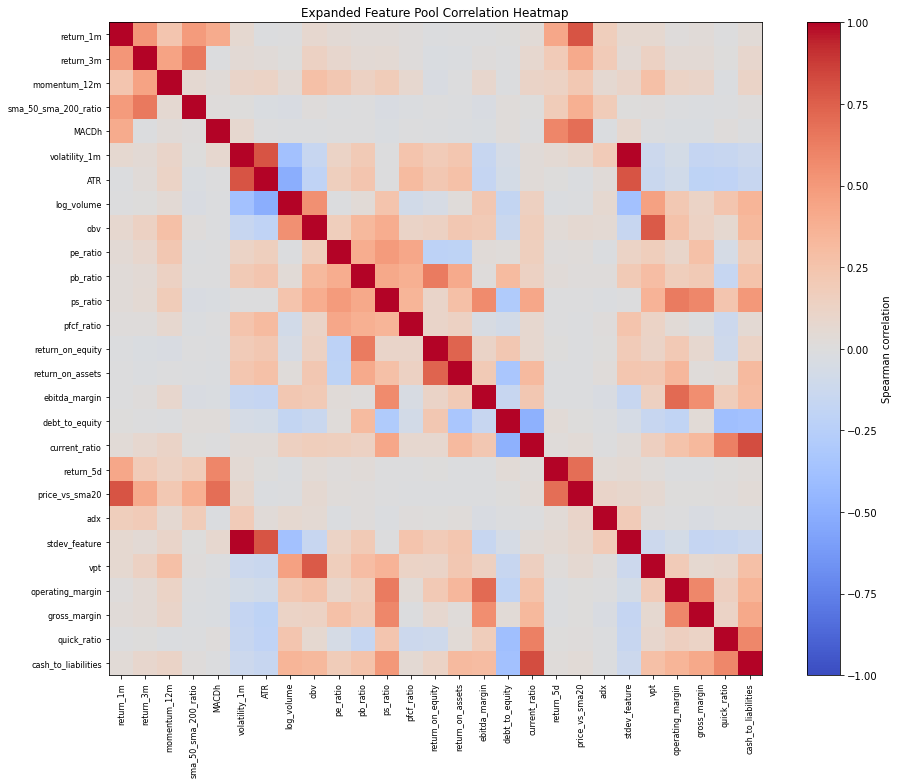

Potential redundancy flags


,feature,family,vif,max_abs_corr,most_correlated_with,mean_ic,abs_mean_ic
0,volatility_1m,Current set,inf,1.000000,stdev_feature,-0.032109,0.032109
1,stdev_feature,Technical candidate,inf,1.000000,volatility_1m,-0.032109,0.032109
2,price_vs_sma20,Technical candidate,6.917257,0.794261,return_1m,-0.035385,0.035385
3,return_on_equity,Fundamental candidate,6.263980,0.729141,return_on_assets,0.002927,0.002927
4,return_on_assets,Fundamental candidate,5.729652,0.729141,return_on_equity,0.009693,0.009693
5,pb_ratio,Fundamental candidate,5.577070,0.639351,return_on_equity,0.040783,0.040783
7,cash_to_liabilities,Fundamental candidate,4.747569,0.820262,current_ratio,0.038631,0.038631
8,current_ratio,Fundamental candidate,4.390185,0.820262,cash_to_liabilities,0.041969,0.041969


Top features by absolute univariate monthly IC


,feature,family,vif,max_abs_corr,most_correlated_with,mean_ic,abs_mean_ic
14,pe_ratio,Fundamental candidate,2.768067,0.487008,ps_ratio,0.049856,0.049856
8,current_ratio,Fundamental candidate,4.390185,0.820262,cash_to_liabilities,0.041969,0.041969
5,pb_ratio,Fundamental candidate,5.577070,0.639351,return_on_equity,0.040783,0.040783
7,cash_to_liabilities,Fundamental candidate,4.747569,0.820262,current_ratio,0.038631,0.038631
6,ps_ratio,Fundamental candidate,4.916150,0.636081,operating_margin,0.037716,0.037716
12,obv,Technical candidate,3.087118,0.770398,vpt,0.037379,0.037379
26,adx,Technical candidate,1.165256,0.192654,volatility_1m,-0.035751,0.035751
2,price_vs_sma20,Technical candidate,6.917257,0.794261,return_1m,-0.035385,0.035385
22,return_5d,Technical candidate,2.152053,0.693996,price_vs_sma20,-0.032164,0.032164
1,stdev_feature,Technical candidate,inf,1.000000,volatility_1m,-0.032109,0.032109


In [14]:
# Add candidate features to the enhanced datasets
train_enhanced = train_df.copy()
test_enhanced = test_df.copy()
if 'Date' not in train_enhanced.columns:
    train_enhanced = train_enhanced.reset_index()
if 'Date' not in test_enhanced.columns:
    test_enhanced = test_enhanced.reset_index()

train_enhanced = add_candidate_features(train_enhanced)
test_enhanced = add_candidate_features(test_enhanced)

# Expanded feature pool
candidate_feature_sets = get_candidate_feature_sets()
all_candidate_features = candidate_feature_sets['technical'] + candidate_feature_sets['fundamental']
expanded_feature_pool = list(dict.fromkeys(feature_cols + all_candidate_features))
available_expanded_features = [
    col for col in expanded_feature_pool
    if col in train_enhanced.columns and train_enhanced[col].notna().sum() > 0
]
missing_expanded_features = sorted(set(expanded_feature_pool) - set(available_expanded_features))

feature_family_lookup = {}
for col in feature_cols:
    feature_family_lookup[col] = 'Current set'
for col in candidate_feature_sets['technical']:
    feature_family_lookup[col] = 'Technical candidate'
for col in candidate_feature_sets['fundamental']:
    feature_family_lookup[col] = 'Fundamental candidate'

feature_availability = pd.DataFrame({
    'feature': expanded_feature_pool,
    'family': [feature_family_lookup.get(col, 'Other') for col in expanded_feature_pool],
    'available_in_train': [col in available_expanded_features for col in expanded_feature_pool],
    'non_null_train_obs': [train_enhanced[col].notna().sum() if col in train_enhanced.columns else 0 for col in expanded_feature_pool]
}).sort_values(['available_in_train', 'family', 'feature'], ascending=[False, True, True]).reset_index(drop=True)

display(feature_availability)
if missing_expanded_features:
    print('Unavailable or empty candidate features:', missing_expanded_features)

# Build diagnostic monthly panel with expanded features
monthly_diagnostic_train_raw = build_month_end_panel(train_enhanced, regime_df, available_expanded_features)
monthly_diagnostic_test_raw = build_month_end_panel(test_enhanced, regime_df, available_expanded_features)
monthly_diagnostic_train_cs, diagnostic_cs_cols = cross_sectional_quantile_transform(monthly_diagnostic_train_raw, available_expanded_features)
monthly_diagnostic_test_cs, _ = cross_sectional_quantile_transform(monthly_diagnostic_test_raw, available_expanded_features)

# Run diagnostics: VIF, correlation, univariate IC
expanded_feature_diagnostic, expanded_feature_corr = build_candidate_diagnostic_table(monthly_diagnostic_train_cs, diagnostic_cs_cols)
expanded_feature_diagnostic['feature_raw'] = expanded_feature_diagnostic['feature'].str.replace('_cs_q', '', regex=False)
expanded_feature_diagnostic['most_correlated_with_raw'] = expanded_feature_diagnostic['most_correlated_with'].str.replace('_cs_q', '', regex=False)
expanded_feature_diagnostic['family'] = expanded_feature_diagnostic['feature_raw'].map(feature_family_lookup)
expanded_feature_diagnostic = expanded_feature_diagnostic[[
    'feature_raw', 'family', 'vif', 'max_abs_corr', 'most_correlated_with_raw', 'mean_ic', 'abs_mean_ic'
]].rename(columns={'feature_raw': 'feature', 'most_correlated_with_raw': 'most_correlated_with'}).sort_values(
    ['vif', 'max_abs_corr', 'abs_mean_ic'], ascending=[False, False, False]
).reset_index(drop=True)

display(expanded_feature_diagnostic)

# Correlation heatmap
plot_corr = expanded_feature_corr.copy()
plot_corr.index = plot_corr.index.str.replace('_cs_q', '', regex=False)
plot_corr.columns = plot_corr.columns.str.replace('_cs_q', '', regex=False)

plt.figure(figsize=(14, 11))
plt.imshow(plot_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Spearman correlation')
plt.xticks(range(len(plot_corr.columns)), plot_corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(plot_corr.index)), plot_corr.index, fontsize=8)
plt.title('Expanded Feature Pool Correlation Heatmap')
plt.tight_layout()
plt.show()

# Redundancy flags & top signal features
high_vif_or_corr = expanded_feature_diagnostic[(expanded_feature_diagnostic['vif'] >= 5) | (expanded_feature_diagnostic['max_abs_corr'] >= 0.8)].copy()
signal_candidates = expanded_feature_diagnostic.sort_values('abs_mean_ic', ascending=False).head(12).copy()

print('Potential redundancy flags')
display(high_vif_or_corr)
print('Top features by absolute univariate monthly IC')
display(signal_candidates)

## 4.1 Cleaner Feature Sets

Based on VIF/correlation/IC diagnostics above, define refined feature sets that avoid high multicollinearity while retaining the strongest signals.

### New feature set:

In [15]:
# Cleaner feature sets based on diagnostics
technical_cleaner_preferred = ['return_1m', 'momentum_12m', 'MACDh', 'adx', 'ATR', 'obv']
fundamental_cleaner_preferred = ['pfcf_ratio', 'return_on_assets', 'ebitda_margin', 'gross_margin',
                                  'quick_ratio', 'debt_to_equity', 'cash_to_liabilities']

cleaner_technical_cols = [col for col in technical_cleaner_preferred if col in available_expanded_features]
cleaner_fundamental_cols = [col for col in fundamental_cleaner_preferred if col in available_expanded_features]
cleaner_all_cols = cleaner_technical_cols + cleaner_fundamental_cols

print('Cleaner technical features:', cleaner_technical_cols)
print('Cleaner fundamental features:', cleaner_fundamental_cols)
print('Cleaner all features:', cleaner_all_cols)

# Build cleaner monthly panels
monthly_clean_train_raw = build_month_end_panel(train_enhanced, regime_df, cleaner_all_cols)
monthly_clean_test_raw = build_month_end_panel(test_enhanced, regime_df, cleaner_all_cols)
monthly_clean_train_cs, monthly_clean_cs_cols = cross_sectional_quantile_transform(monthly_clean_train_raw, cleaner_all_cols)
monthly_clean_test_cs, _ = cross_sectional_quantile_transform(monthly_clean_test_raw, cleaner_all_cols)

print(f'\nCleaner monthly train shape: {monthly_clean_train_cs.shape}')
print(f'Cleaner monthly test shape: {monthly_clean_test_cs.shape}')
print(f'Train date range: {monthly_clean_train_cs["Date"].min().date()} -> {monthly_clean_train_cs["Date"].max().date()}')
print(f'Test date range: {monthly_clean_test_cs["Date"].min().date()} -> {monthly_clean_test_cs["Date"].max().date()}')

feature_set_configs = {
    'Cleaner all features': cleaner_all_cols,
    'Cleaner technical-only': cleaner_technical_cols,
    'Cleaner fundamental-only': cleaner_fundamental_cols
}

Cleaner technical features: ['return_1m', 'momentum_12m', 'MACDh', 'adx', 'ATR', 'obv']
Cleaner fundamental features: ['pfcf_ratio', 'return_on_assets', 'ebitda_margin', 'gross_margin', 'quick_ratio', 'debt_to_equity', 'cash_to_liabilities']
Cleaner all features: ['return_1m', 'momentum_12m', 'MACDh', 'adx', 'ATR', 'obv', 'pfcf_ratio', 'return_on_assets', 'ebitda_margin', 'gross_margin', 'quick_ratio', 'debt_to_equity', 'cash_to_liabilities']

Cleaner monthly train shape: (4240, 119)
Cleaner monthly test shape: (680, 119)
Train date range: 2011-01-31 -> 2019-10-31
Test date range: 2020-12-31 -> 2022-04-29


# 5. Baseline Models (LightGBM on Cleaner Feature Sets)

Compare pure baseline, state-as-feature, and regime-aware LightGBM across the three cleaner feature sets.

In [16]:
cleaner_feature_set_results = []
cleaner_feature_set_model_store = {}

for feature_set_label, raw_cols in feature_set_configs.items():
    print(f'\n==================== {feature_set_label} ====================')
    results_df, store = run_monthly_triplet_comparison(
        monthly_clean_train_cs, monthly_clean_test_cs,
        raw_feature_cols=raw_cols, label=feature_set_label, build_model=build_lightgbm_model
    )
    cleaner_feature_set_results.append(results_df)
    cleaner_feature_set_model_store[feature_set_label] = store

cleaner_feature_set_comparison = pd.concat(cleaner_feature_set_results, ignore_index=True)

print('\n===== Cleaner feature set comparison =====')
display(cleaner_feature_set_comparison)

cleaner_feature_set_test_ic = cleaner_feature_set_comparison.pivot(index='Feature Set', columns='Model', values='Test IC')
cleaner_feature_set_test_r2_oos = cleaner_feature_set_comparison.pivot(index='Feature Set', columns='Model', values='Test R2_oos')
cleaner_feature_set_test_mse = cleaner_feature_set_comparison.pivot(index='Feature Set', columns='Model', values='Test MSE')

print('Cleaner set: Test IC')
display(cleaner_feature_set_test_ic)
print('Cleaner set: Test R2_oos')
display(cleaner_feature_set_test_r2_oos)


==================== Cleaner all features ====================
===== Cleaner all features: pure baseline =====
Fold 1: train 2011-01-31 -> 2018-04-30 (3520 rows), val 2018-05-31 -> 2018-10-31 (240 rows), MSE = 0.004166, IC = 0.0557
Fold 2: train 2011-01-31 -> 2018-10-31 (3760 rows), val 2018-11-30 -> 2019-04-30 (240 rows), MSE = 0.005168, IC = -0.0339
Fold 3: train 2011-01-31 -> 2019-04-30 (4000 rows), val 2019-05-31 -> 2019-10-31 (240 rows), MSE = 0.003297, IC = 0.1019
Average MSE: 0.004210, Average IC: 0.0413

===== Cleaner all features: state as feature =====
Fold 1: train 2011-01-31 -> 2018-04-30 (3520 rows), val 2018-05-31 -> 2018-10-31 (240 rows), MSE = 0.004254, IC = 0.0532
Fold 2: train 2011-01-31 -> 2018-10-31 (3760 rows), val 2018-11-30 -> 2019-04-30 (240 rows), MSE = 0.005292, IC = -0.1008
Fold 3: train 2011-01-31 -> 2019-04-30 (4000 rows), val 2019-05-31 -> 2019-10-31 (240 rows), MSE = 0.003313, IC = 0.0621
Average MSE: 0.004287, Average IC: 0.0048

===== Cleaner all featu

,Feature Set,Model,CV MSE,CV RMSE,CV MAE,CV R2,CV R2_oos,CV IC,Test MSE,Test RMSE,Test MAE,Test R2,Test R2_oos,Test IC
0,Cleaner all features,Monthly LightGBM (pure baseline),0.004210,0.064617,0.048672,-0.073782,-0.056128,0.041263,0.005883,0.076700,0.058910,-0.024350,-0.024032,0.020802
1,Cleaner all features,Monthly LightGBM (state as feature),0.004287,0.065177,0.049197,-0.091388,-0.073542,0.004792,0.005823,0.076311,0.058806,-0.014002,-0.013687,0.050348
2,Cleaner all features,Monthly LightGBM (regime-aware),0.004500,0.066714,0.050282,-0.140969,-0.122399,0.018909,0.006056,0.077819,0.060855,-0.054458,-0.054131,0.023401
3,Cleaner technical-only,Monthly LightGBM (pure baseline),0.004262,0.065032,0.049422,-0.088474,-0.070531,0.019748,0.005843,0.076441,0.058680,-0.017458,-0.017142,0.084842
4,Cleaner technical-only,Monthly LightGBM (state as feature),0.004299,0.065240,0.049678,-0.092721,-0.074761,0.003472,0.005925,0.076973,0.059224,-0.031670,-0.031350,0.028832
5,Cleaner technical-only,Monthly LightGBM (regime-aware),0.004559,0.067100,0.050957,-0.152807,-0.134038,-0.008294,0.006213,0.078820,0.060430,-0.081764,-0.081429,0.064269
6,Cleaner fundamental-only,Monthly LightGBM (pure baseline),0.004301,0.065253,0.049470,-0.092493,-0.075086,-0.052888,0.005753,0.075850,0.058154,-0.001775,-0.001464,0.058199
7,Cleaner fundamental-only,Monthly LightGBM (state as feature),0.004338,0.065460,0.049962,-0.096636,-0.079089,-0.052124,0.005649,0.075157,0.057829,0.016429,0.016734,0.108331
8,Cleaner fundamental-only,Monthly LightGBM (regime-aware),0.004433,0.066232,0.050577,-0.125613,-0.107111,-0.027367,0.005864,0.076577,0.059156,-0.021076,-0.020759,0.087023


Cleaner set: Test IC


Model,Monthly LightGBM (pure baseline),Monthly LightGBM (regime-aware),Monthly LightGBM (state as feature)
Feature Set,,,
Cleaner all features,0.020802,0.023401,0.050348
Cleaner fundamental-only,0.058199,0.087023,0.108331
Cleaner technical-only,0.084842,0.064269,0.028832


Cleaner set: Test R2_oos


Model,Monthly LightGBM (pure baseline),Monthly LightGBM (regime-aware),Monthly LightGBM (state as feature)
Feature Set,,,
Cleaner all features,-0.024032,-0.054131,-0.013687
Cleaner fundamental-only,-0.001464,-0.020759,0.016734
Cleaner technical-only,-0.017142,-0.081429,-0.031350


# 6. Model Family Comparison (LightGBM vs XGBoost vs LSTM)

All three model families are evaluated on the same cleaner monthly feature sets under the `state as feature` design for comparability.

In [17]:
# LSTM configuration
LSTM_LOOKBACK = 6
LSTM_MAX_EPOCHS = 100
LSTM_PATIENCE = 10
LSTM_BATCH_SIZE = 32
LSTM_LEARNING_RATE = 1e-3

# --- XGBoost state-as-feature comparison helper ---
def run_xgboost_state_feature_comparison(train_panel, test_panel, raw_feature_cols, label):
    cs_feature_cols = map_raw_to_cs_features(raw_feature_cols)
    X_train = train_panel.set_index('Date')[cs_feature_cols + ['state']].sort_index()
    y_train = train_panel.set_index('Date')['future_return_1m'].sort_index()
    X_test = test_panel.set_index('Date')[cs_feature_cols + ['state']].sort_index()
    y_test = test_panel.set_index('Date')['future_return_1m'].sort_index()
    model = build_xgboost_model()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = evaluate_regression_metrics_monthly(y_test, y_pred, benchmark_mean=y_train.mean())
    return {
        'Model Family': 'XGBoost', 'Feature Set': label,
        'Test MSE': metrics['mse'], 'Test RMSE': metrics['rmse'], 'Test MAE': metrics['mae'],
        'Test R2': metrics['r2'], 'Test R2_oos': metrics['r2_oos'], 'Test IC': metrics['ic']
    }

# --- LSTM sequence dataset builder ---
def build_lstm_sequence_dataset(train_panel, test_panel, raw_feature_cols, lookback=LSTM_LOOKBACK):
    cs_feature_cols = map_raw_to_cs_features(raw_feature_cols)
    seq_feature_cols = cs_feature_cols + ['state']
    combined = pd.concat([train_panel.assign(sample_split='train'), test_panel.assign(sample_split='test')], ignore_index=True)
    combined['Date'] = pd.to_datetime(combined['Date'])
    combined = combined.sort_values(['ticker', 'Date']).reset_index(drop=True)

    X_train_seq, y_train_seq, train_meta = [], [], []
    X_test_seq, y_test_seq, test_meta = [], [], []

    for ticker_value, ticker_df in combined.groupby('ticker'):
        ticker_df = ticker_df.sort_values('Date').reset_index(drop=True)
        feature_array = ticker_df[seq_feature_cols].astype(float).to_numpy()
        target_array = ticker_df['future_return_1m'].astype(float).to_numpy()
        split_array = ticker_df['sample_split'].to_numpy()
        date_array = pd.to_datetime(ticker_df['Date']).to_numpy()
        state_array = ticker_df['state'].to_numpy()

        for end_idx in range(lookback - 1, len(ticker_df)):
            sequence = feature_array[end_idx - lookback + 1:end_idx + 1]
            target = target_array[end_idx]
            if np.isnan(sequence).any() or np.isnan(target):
                continue
            meta_row = {'ticker': ticker_value, 'Date': pd.Timestamp(date_array[end_idx]), 'state': state_array[end_idx]}
            if split_array[end_idx] == 'train':
                X_train_seq.append(sequence); y_train_seq.append(target); train_meta.append(meta_row)
            else:
                X_test_seq.append(sequence); y_test_seq.append(target); test_meta.append(meta_row)

    if len(X_train_seq) == 0 or len(X_test_seq) == 0:
        raise ValueError('No valid LSTM sequences were created.')

    X_train_seq = np.asarray(X_train_seq, dtype=np.float32)
    y_train_seq = np.asarray(y_train_seq, dtype=np.float32)
    X_test_seq = np.asarray(X_test_seq, dtype=np.float32)
    y_test_seq = np.asarray(y_test_seq, dtype=np.float32)
    train_meta = pd.DataFrame(train_meta).sort_values('Date').reset_index(drop=True)
    test_meta = pd.DataFrame(test_meta).sort_values('Date').reset_index(drop=True)

    train_order = train_meta.index.to_numpy(); test_order = test_meta.index.to_numpy()
    X_train_seq = X_train_seq[train_order]; y_train_seq = y_train_seq[train_order]
    X_test_seq = X_test_seq[test_order]; y_test_seq = y_test_seq[test_order]

    scaler = StandardScaler()
    scaler.fit(X_train_seq.reshape(-1, X_train_seq.shape[-1]))
    X_train_seq = scaler.transform(X_train_seq.reshape(-1, X_train_seq.shape[-1])).reshape(X_train_seq.shape)
    X_test_seq = scaler.transform(X_test_seq.reshape(-1, X_test_seq.shape[-1])).reshape(X_test_seq.shape)
    return X_train_seq, y_train_seq, X_test_seq, y_test_seq, train_meta, test_meta

# --- PyTorch LSTM training ---
def fit_predict_lstm_sequences(X_train, y_train, X_test, max_epochs=LSTM_MAX_EPOCHS, patience=LSTM_PATIENCE):
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    torch.manual_seed(42)
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = 'mps'
    elif torch.cuda.is_available():
        device = 'cuda'
    else:
        device = 'cpu'

    class TorchLSTMRegressor(nn.Module):
        def __init__(self, input_size, hidden_size=32):
            super().__init__()
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
            self.head = nn.Sequential(nn.Linear(hidden_size, 16), nn.ReLU(), nn.Linear(16, 1))
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.head(out[:, -1, :]).squeeze(-1)

    val_size = max(1, int(len(X_train) * 0.1))
    if len(X_train) <= val_size + 4:
        X_train_main, y_train_main = X_train, y_train
        X_val, y_val = X_train, y_train
    else:
        X_train_main, y_train_main = X_train[:-val_size], y_train[:-val_size]
        X_val, y_val = X_train[-val_size:], y_train[-val_size:]

    X_train_t = torch.tensor(X_train_main, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_main, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    model = TorchLSTMRegressor(input_size=X_train.shape[2]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LSTM_LEARNING_RATE)
    criterion = nn.MSELoss()
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=LSTM_BATCH_SIZE, shuffle=False)

    best_state, best_val_loss, patience_left, epochs_trained = None, np.inf, patience, 0
    for epoch in range(max_epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t.to(device)), y_val_t.to(device)).item()
        epochs_trained = epoch + 1
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t.to(device)).detach().cpu().numpy().reshape(-1)
    return y_pred, 'LSTM (PyTorch)', epochs_trained

# ===== Run comparison =====
comparison_rows = []

# Reuse LightGBM results from the cleaner feature set comparison
lightgbm_reference = cleaner_feature_set_comparison[
    cleaner_feature_set_comparison['Model'] == 'Monthly LightGBM (state as feature)'
][['Feature Set', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', 'Test R2_oos', 'Test IC']].copy()
lightgbm_reference['Model Family'] = 'LightGBM'
comparison_rows.extend(
    lightgbm_reference[['Model Family', 'Feature Set', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', 'Test R2_oos', 'Test IC']].to_dict('records')
)

print('===== Horizontal model comparison: LightGBM vs XGBoost vs LSTM =====')
print(f'LSTM: PyTorch, max_epochs={LSTM_MAX_EPOCHS}, early-stopping patience={LSTM_PATIENCE}.')

for feature_set_label, raw_cols in feature_set_configs.items():
    print(f'\n----- {feature_set_label} -----')

    # XGBoost
    xgb_row = run_xgboost_state_feature_comparison(monthly_clean_train_cs, monthly_clean_test_cs, raw_cols, feature_set_label)
    comparison_rows.append(xgb_row)
    print(f"XGBoost Test IC = {xgb_row['Test IC']:.4f}, Test R2_oos = {xgb_row['Test R2_oos']:.4f}")

    # LSTM
    try:
        X_train_seq, y_train_seq, X_test_seq, y_test_seq, train_meta_seq, test_meta_seq = build_lstm_sequence_dataset(
            monthly_clean_train_cs, monthly_clean_test_cs, raw_cols, lookback=LSTM_LOOKBACK
        )
        lstm_pred, lstm_backend, epochs_trained = fit_predict_lstm_sequences(X_train_seq, y_train_seq, X_test_seq, max_epochs=LSTM_MAX_EPOCHS, patience=LSTM_PATIENCE)
        if lstm_pred is not None:
            lstm_metrics = evaluate_regression_metrics_monthly(y_test_seq, lstm_pred, benchmark_mean=y_train_seq.mean())
            lstm_row = {
                'Model Family': lstm_backend, 'Feature Set': feature_set_label,
                'Test MSE': lstm_metrics['mse'], 'Test RMSE': lstm_metrics['rmse'], 'Test MAE': lstm_metrics['mae'],
                'Test R2': lstm_metrics['r2'], 'Test R2_oos': lstm_metrics['r2_oos'], 'Test IC': lstm_metrics['ic']
            }
            comparison_rows.append(lstm_row)
            print(f"{lstm_backend} trained for {epochs_trained} epochs; Test IC = {lstm_row['Test IC']:.4f}, Test R2_oos = {lstm_row['Test R2_oos']:.4f}")
    except Exception as lstm_error:
        print(f'LSTM failed for {feature_set_label}: {lstm_error}')

model_family_comparison = pd.DataFrame(comparison_rows).sort_values(['Feature Set', 'Model Family']).reset_index(drop=True)
print('\n===== Model family comparison table =====')
display(model_family_comparison)

model_family_test_ic = model_family_comparison.pivot(index='Feature Set', columns='Model Family', values='Test IC')
print('===== Test IC by model family and feature set =====')
display(model_family_test_ic)

model_family_test_r2_oos = model_family_comparison.pivot(index='Feature Set', columns='Model Family', values='Test R2_oos')
print('===== Test R2_oos by model family and feature set =====')
display(model_family_test_r2_oos)

===== Horizontal model comparison: LightGBM vs XGBoost vs LSTM =====
LSTM: PyTorch, max_epochs=100, early-stopping patience=10.

----- Cleaner all features -----
XGBoost Test IC = 0.0599, Test R2_oos = -0.0054
LSTM (PyTorch) trained for 13 epochs; Test IC = 0.0230, Test R2_oos = -0.0100

----- Cleaner technical-only -----
XGBoost Test IC = 0.0579, Test R2_oos = -0.0139
LSTM (PyTorch) trained for 12 epochs; Test IC = 0.1242, Test R2_oos = 0.0079

----- Cleaner fundamental-only -----
XGBoost Test IC = 0.0797, Test R2_oos = 0.0158
LSTM (PyTorch) trained for 15 epochs; Test IC = 0.0333, Test R2_oos = -0.0279

===== Model family comparison table =====


,Model Family,Feature Set,Test MSE,Test RMSE,Test MAE,Test R2,Test R2_oos,Test IC
0,LSTM (PyTorch),Cleaner all features,0.005802,0.076173,0.058389,-0.010342,-0.010042,0.023047
1,LightGBM,Cleaner all features,0.005823,0.076311,0.058806,-0.014002,-0.013687,0.050348
2,XGBoost,Cleaner all features,0.005776,0.075999,0.058169,-0.005710,-0.005398,0.059861
3,LSTM (PyTorch),Cleaner fundamental-only,0.005905,0.076842,0.058855,-0.028158,-0.027852,0.033318
4,LightGBM,Cleaner fundamental-only,0.005649,0.075157,0.057829,0.016429,0.016734,0.108331
5,XGBoost,Cleaner fundamental-only,0.005654,0.075193,0.057595,0.015492,0.015798,0.079729
6,LSTM (PyTorch),Cleaner technical-only,0.005700,0.075496,0.057751,0.007562,0.007857,0.124185
7,LightGBM,Cleaner technical-only,0.005925,0.076973,0.059224,-0.031670,-0.031350,0.028832
8,XGBoost,Cleaner technical-only,0.005825,0.076320,0.058434,-0.014241,-0.013926,0.057925


===== Test IC by model family and feature set =====


Model Family,LSTM (PyTorch),LightGBM,XGBoost
Feature Set,,,
Cleaner all features,0.023047,0.050348,0.059861
Cleaner fundamental-only,0.033318,0.108331,0.079729
Cleaner technical-only,0.124185,0.028832,0.057925


===== Test R2_oos by model family and feature set =====


Model Family,LSTM (PyTorch),LightGBM,XGBoost
Feature Set,,,
Cleaner all features,-0.010042,-0.013687,-0.005398
Cleaner fundamental-only,-0.027852,0.016734,0.015798
Cleaner technical-only,0.007857,-0.031350,-0.013926


# 7. Report Charts, LSTM Tuning & Regime-Aware Extension

1. Grouped bar charts for the model-family comparison
2. Targeted hyperparameter tuning for `Cleaner technical-only` PyTorch LSTM
3. XGBoost design comparison: `state as feature` vs `regime-aware`
4. LSTM design comparison: `state as feature` vs `regime-aware`
5. Regime-aware model-family comparison: LightGBM vs XGBoost vs LSTM

===== Report chart: model-family Test IC =====


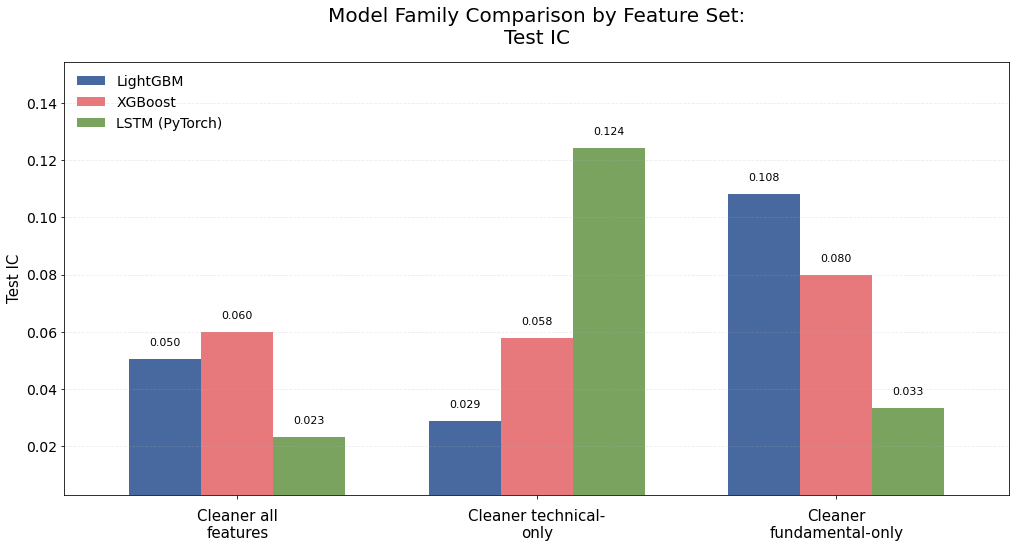

===== Report chart: model-family Test R2_oos =====


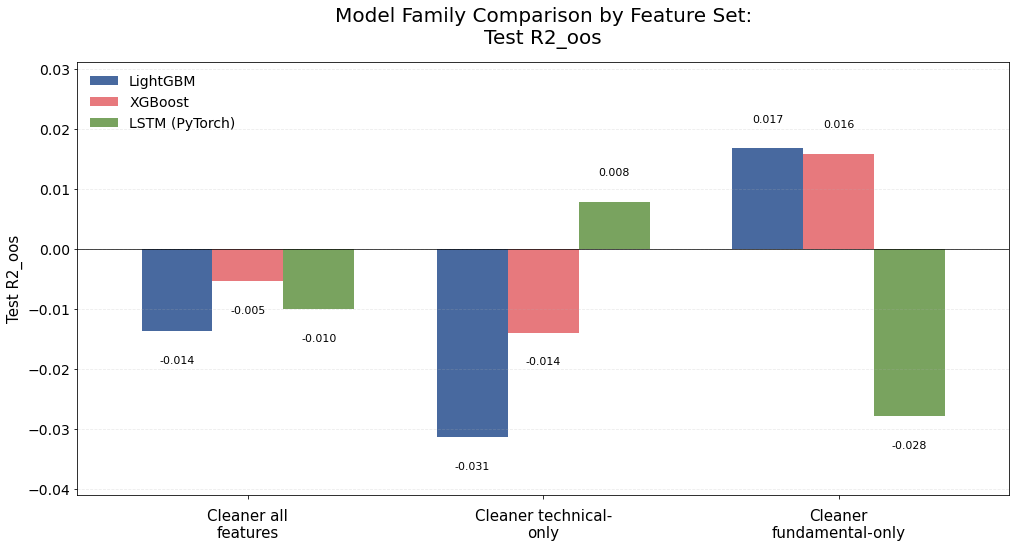


===== Cleaner technical-only LSTM tuning =====
Tuning split: 94 train months, 12 validation months.
Config 1: lookback=3, hidden=16, lr=0.001, batch=32 -> Val IC = 0.0266, Val R2_oos = -0.0173, epochs = 14
Config 2: lookback=6, hidden=32, lr=0.001, batch=32 -> Val IC = -0.0092, Val R2_oos = -0.0063, epochs = 12
Config 3: lookback=9, hidden=32, lr=0.001, batch=32 -> Val IC = -0.0681, Val R2_oos = -0.0347, epochs = 12
Config 4: lookback=6, hidden=64, lr=0.001, batch=32 -> Val IC = -0.0341, Val R2_oos = -0.0125, epochs = 12
Config 5: lookback=6, hidden=32, lr=0.0005, batch=32 -> Val IC = -0.0125, Val R2_oos = -0.0102, epochs = 13
Config 6: lookback=6, hidden=32, lr=0.001, batch=16 -> Val IC = 0.0156, Val R2_oos = -0.0085, epochs = 13
Config 7: lookback=9, hidden=64, lr=0.0005, batch=16 -> Val IC = -0.0690, Val R2_oos = -0.0410, epochs = 12
Config 8: lookback=3, hidden=32, lr=0.0005, batch=16 -> Val IC = 0.0514, Val R2_oos = 0.0025, epochs = 12

Top tuning results:


,Config ID,lookback,hidden_size,dense_size,learning_rate,batch_size,epochs_trained,Validation MSE,Validation RMSE,Validation MAE,Validation R2,Validation R2_oos,Validation IC
0,8,3,32,16,0.0005,16,12,0.004009,0.063318,0.048407,0.002381,0.002468,0.051389
1,1,3,16,8,0.0010,32,14,0.004089,0.063943,0.048786,-0.017390,-0.017302,0.026564
2,6,6,32,16,0.0010,16,13,0.004053,0.063665,0.049161,-0.008586,-0.008534,0.015563
3,2,6,32,16,0.0010,32,12,0.004044,0.063596,0.048722,-0.006380,-0.006327,-0.009230
4,5,6,32,16,0.0005,32,13,0.004060,0.063720,0.048931,-0.010302,-0.010250,-0.012451
5,4,6,64,32,0.0010,32,12,0.004069,0.063790,0.048514,-0.012524,-0.012471,-0.034101
6,3,9,32,16,0.0010,32,12,0.004160,0.064495,0.049025,-0.035041,-0.034708,-0.068138
7,7,9,64,32,0.0005,16,12,0.004185,0.064691,0.048997,-0.041339,-0.041003,-0.069040


Best validation config:


,Config ID,lookback,hidden_size,dense_size,learning_rate,batch_size,epochs_trained,Validation MSE,Validation RMSE,Validation MAE,Validation R2,Validation R2_oos,Validation IC
0,8.0,3.0,32.0,16.0,0.0005,16.0,12.0,0.004009,0.063318,0.048407,0.002381,0.002468,0.051389



Cleaner technical-only: tree models vs tuned LSTM


,Model Family,Feature Set,Test MSE,Test RMSE,Test MAE,Test R2,Test R2_oos,Test IC
0,LSTM (PyTorch),Cleaner technical-only,0.005700,0.075496,0.057751,0.007562,0.007857,0.124185
1,"LSTM (PyTorch, tuned)",Cleaner technical-only,0.005727,0.075675,0.057721,0.002825,0.003177,0.098258
2,XGBoost,Cleaner technical-only,0.005825,0.076320,0.058434,-0.014241,-0.013926,0.057925
3,LightGBM,Cleaner technical-only,0.005925,0.076973,0.059224,-0.031670,-0.031350,0.028832



===== XGBoost design comparison: state as feature vs regime-aware =====

----- Cleaner all features: state as feature -----
Fold 1: train 2011-01-31 -> 2018-04-30 (3520 rows), val 2018-05-31 -> 2018-10-31 (240 rows), MSE = 0.004080, IC = 0.1361
Fold 2: train 2011-01-31 -> 2018-10-31 (3760 rows), val 2018-11-30 -> 2019-04-30 (240 rows), MSE = 0.005140, IC = -0.0754
Fold 3: train 2011-01-31 -> 2019-04-30 (4000 rows), val 2019-05-31 -> 2019-10-31 (240 rows), MSE = 0.003281, IC = 0.0328
Average MSE: 0.004167, Average IC: 0.0312

----- Cleaner all features: regime-aware -----
Fold 1: train 2011-01-31 -> 2018-04-30 (3520 rows), val 2018-05-31 -> 2018-10-31 (240 rows), MSE = 0.004199, IC = 0.0878
Fold 2: train 2011-01-31 -> 2018-10-31 (3760 rows), val 2018-11-30 -> 2019-04-30 (240 rows), MSE = 0.005332, IC = -0.0318
Fold 3: train 2011-01-31 -> 2019-04-30 (4000 rows), val 2019-05-31 -> 2019-10-31 (240 rows), MSE = 0.003281, IC = 0.0008
Average MSE: 0.004271, Average IC: 0.0190

----- Cleaner 

,Model Design,Feature Set,CV MSE,CV IC,Test MSE,Test RMSE,Test MAE,Test R2,Test R2_oos,Test IC
0,XGBoost (regime-aware),Cleaner all features,0.004271,0.018959,0.005873,0.076634,0.059369,-0.022607,-0.022290,0.040846
1,XGBoost (state as feature),Cleaner all features,0.004167,0.031167,0.005776,0.075999,0.058169,-0.005710,-0.005398,0.059861
2,XGBoost (regime-aware),Cleaner fundamental-only,0.004258,-0.009043,0.005583,0.074722,0.057462,0.027799,0.028101,0.121071
3,XGBoost (state as feature),Cleaner fundamental-only,0.004168,-0.022744,0.005654,0.075193,0.057595,0.015492,0.015798,0.079729
4,XGBoost (regime-aware),Cleaner technical-only,0.004264,0.006144,0.006072,0.077922,0.059572,-0.057271,-0.056943,0.042211
5,XGBoost (state as feature),Cleaner technical-only,0.004158,0.036946,0.005825,0.076320,0.058434,-0.014241,-0.013926,0.057925


===== Report chart: XGBoost design comparison Test IC =====


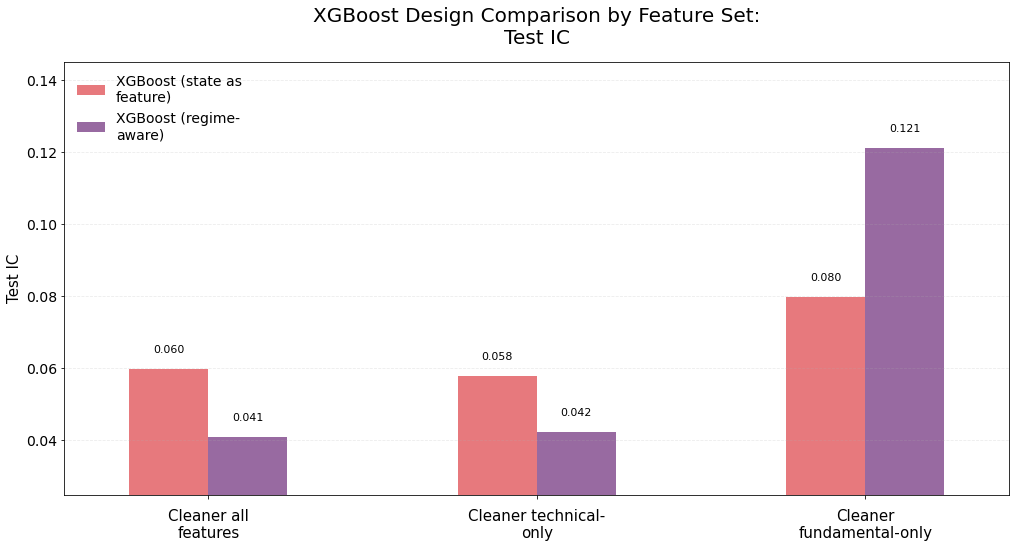

===== Report chart: XGBoost design comparison Test R2_oos =====


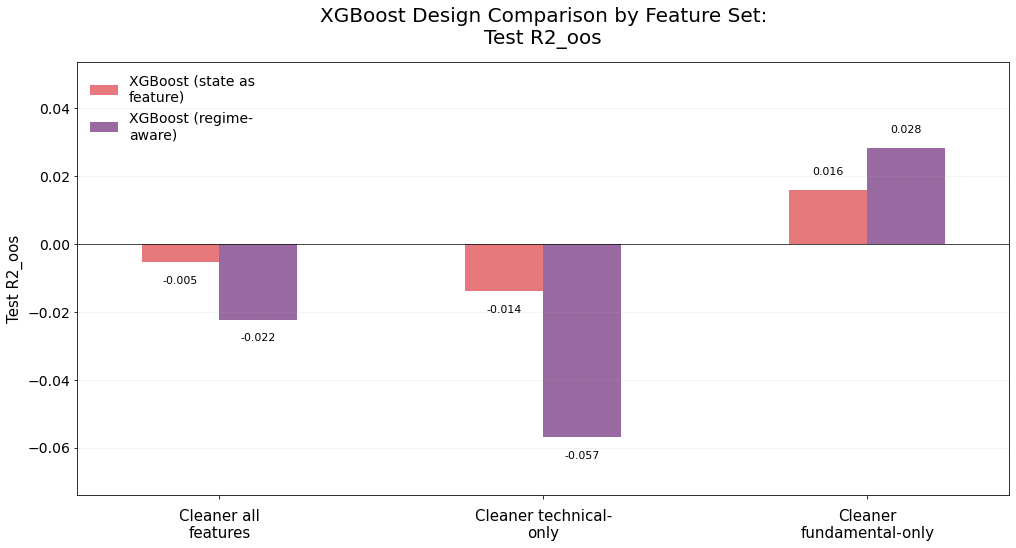

In [23]:
# ===== Report charts =====
report_feature_order = ['Cleaner all features', 'Cleaner technical-only', 'Cleaner fundamental-only']
report_family_order = ['LightGBM', 'XGBoost', 'LSTM (PyTorch)']
report_palette = {'LightGBM': '#345995', 'XGBoost': '#e56b6f', 'LSTM (PyTorch)': '#6a994e'}

def plot_grouped_metric_bars(comparison_df, metric_col, title, ylabel, model_order, palette):
    plot_df = comparison_df.copy()
    plot_df = plot_df[plot_df['Model Family'].isin(model_order)].copy()
    plot_df['Feature Set'] = pd.Categorical(plot_df['Feature Set'], categories=report_feature_order, ordered=True)
    plot_df['Model Family'] = pd.Categorical(plot_df['Model Family'], categories=model_order, ordered=True)
    plot_df = plot_df.sort_values(['Feature Set', 'Model Family'])

    x = np.arange(len(report_feature_order))
    width = 0.24
    fig, ax = plt.subplots(figsize=(14, 7.5), constrained_layout=True)

    wrapped_feature_labels = [fill(label, width=18) for label in report_feature_order]
    value_columns = []

    for idx, model_family in enumerate(model_order):
        family_df = plot_df[plot_df['Model Family'] == model_family]
        values = []
        for feature_set in report_feature_order:
            subset = family_df[family_df['Feature Set'] == feature_set]
            values.append(subset[metric_col].iloc[0] if not subset.empty else np.nan)
        value_columns.extend([value for value in values if pd.notna(value)])

        positions = x + (idx - (len(model_order) - 1) / 2) * width
        bars = ax.bar(
            positions,
            values,
            width=width,
            label=fill(str(model_family), width=18),
            color=palette.get(model_family, '#888888'),
            alpha=0.9
        )
        for bar, value in zip(bars, values):
            if pd.notna(value):
                text_offset = 0.004 if value >= 0 else -0.004
                va = 'bottom' if value >= 0 else 'top'
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value + text_offset,
                    f'{value:.3f}',
                    ha='center',
                    va=va,
                    fontsize=11,
                    clip_on=False
                )

    if value_columns:
        value_min = min(value_columns)
        value_max = max(value_columns)
        value_span = max(value_max - value_min, 0.02)
        ax.set_ylim(value_min - 0.2 * value_span, value_max + 0.3 * value_span)

    ax.axhline(0, color='black', linewidth=1, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(wrapped_feature_labels, fontsize=15)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_title(fill(title, width=42), fontsize=20, pad=18)
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', pad=10)
    ax.legend(frameon=False, fontsize=14, loc='upper left')
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.margins(x=0.08)
    plt.show()

print('===== Report chart: model-family Test IC =====')
plot_grouped_metric_bars(model_family_comparison, 'Test IC', 'Model Family Comparison by Feature Set: Test IC', 'Test IC', report_family_order, report_palette)

print('===== Report chart: model-family Test R2_oos =====')
plot_grouped_metric_bars(model_family_comparison, 'Test R2_oos', 'Model Family Comparison by Feature Set: Test R2_oos', 'Test R2_oos', report_family_order, report_palette)

# ===== Cleaner technical-only LSTM tuning =====
def fit_predict_lstm_sequences_tuned(X_train, y_train, X_test, hidden_size=32, dense_size=16, learning_rate=1e-3, batch_size=32, max_epochs=100, patience=10):
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    torch.manual_seed(42)
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = 'mps'
    elif torch.cuda.is_available():
        device = 'cuda'
    else:
        device = 'cpu'

    class TunedTorchLSTMRegressor(nn.Module):
        def __init__(self, input_size, hidden_size, dense_size):
            super().__init__()
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
            self.head = nn.Sequential(nn.Linear(hidden_size, dense_size), nn.ReLU(), nn.Linear(dense_size, 1))
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.head(out[:, -1, :]).squeeze(-1)

    val_size = max(1, int(len(X_train) * 0.1))
    if len(X_train) <= val_size + 4:
        X_tm, y_tm, X_v, y_v = X_train, y_train, X_train, y_train
    else:
        X_tm, y_tm = X_train[:-val_size], y_train[:-val_size]
        X_v, y_v = X_train[-val_size:], y_train[-val_size:]

    X_t = torch.tensor(X_tm, dtype=torch.float32); y_t = torch.tensor(y_tm, dtype=torch.float32)
    X_vt = torch.tensor(X_v, dtype=torch.float32); y_vt = torch.tensor(y_v, dtype=torch.float32)
    X_tt = torch.tensor(X_test, dtype=torch.float32)

    model = TunedTorchLSTMRegressor(input_size=X_train.shape[2], hidden_size=hidden_size, dense_size=dense_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    train_loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)

    best_state, best_val_loss, patience_left, epochs_trained = None, np.inf, patience, 0
    for epoch in range(max_epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad(); loss = criterion(model(bx), by); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            vl = criterion(model(X_vt.to(device)), y_vt.to(device)).item()
        epochs_trained = epoch + 1
        if vl < best_val_loss:
            best_val_loss = vl; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}; patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0: break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_tt.to(device)).detach().cpu().numpy().reshape(-1)
    return y_pred, epochs_trained

print('\n===== Cleaner technical-only LSTM tuning =====')
technical_only_label = 'Cleaner technical-only'
technical_only_cols = cleaner_technical_cols
train_months_for_tuning = pd.Index(sorted(pd.to_datetime(monthly_clean_train_cs['Date']).unique()))
validation_month_count = 12
validation_months = train_months_for_tuning[-validation_month_count:]

tuning_train_panel = monthly_clean_train_cs[~pd.to_datetime(monthly_clean_train_cs['Date']).isin(validation_months)].copy()
tuning_validation_panel = monthly_clean_train_cs[pd.to_datetime(monthly_clean_train_cs['Date']).isin(validation_months)].copy()
print(f'Tuning split: {len(train_months_for_tuning) - validation_month_count} train months, {validation_month_count} validation months.')

technical_lstm_tuning_grid = [
    {'lookback': 3, 'hidden_size': 16, 'dense_size': 8, 'learning_rate': 1e-3, 'batch_size': 32},
    {'lookback': 6, 'hidden_size': 32, 'dense_size': 16, 'learning_rate': 1e-3, 'batch_size': 32},
    {'lookback': 9, 'hidden_size': 32, 'dense_size': 16, 'learning_rate': 1e-3, 'batch_size': 32},
    {'lookback': 6, 'hidden_size': 64, 'dense_size': 32, 'learning_rate': 1e-3, 'batch_size': 32},
    {'lookback': 6, 'hidden_size': 32, 'dense_size': 16, 'learning_rate': 5e-4, 'batch_size': 32},
    {'lookback': 6, 'hidden_size': 32, 'dense_size': 16, 'learning_rate': 1e-3, 'batch_size': 16},
    {'lookback': 9, 'hidden_size': 64, 'dense_size': 32, 'learning_rate': 5e-4, 'batch_size': 16},
    {'lookback': 3, 'hidden_size': 32, 'dense_size': 16, 'learning_rate': 5e-4, 'batch_size': 16}
]

technical_lstm_tuning_rows = []
for config_id, config in enumerate(technical_lstm_tuning_grid, start=1):
    X_train_seq_tune, y_train_seq_tune, X_val_seq_tune, y_val_seq_tune, _, _ = build_lstm_sequence_dataset(
        tuning_train_panel, tuning_validation_panel, technical_only_cols, lookback=config['lookback']
    )
    val_pred, epochs_used = fit_predict_lstm_sequences_tuned(
        X_train_seq_tune, y_train_seq_tune, X_val_seq_tune,
        hidden_size=config['hidden_size'], dense_size=config['dense_size'],
        learning_rate=config['learning_rate'], batch_size=config['batch_size'],
        max_epochs=LSTM_MAX_EPOCHS, patience=LSTM_PATIENCE
    )
    val_metrics = evaluate_regression_metrics_monthly(y_val_seq_tune, val_pred, benchmark_mean=y_train_seq_tune.mean())
    technical_lstm_tuning_rows.append({
        'Config ID': config_id, **config, 'epochs_trained': epochs_used,
        'Validation MSE': val_metrics['mse'], 'Validation RMSE': val_metrics['rmse'],
        'Validation MAE': val_metrics['mae'], 'Validation R2': val_metrics['r2'],
        'Validation R2_oos': val_metrics['r2_oos'], 'Validation IC': val_metrics['ic']
    })
    print(f"Config {config_id}: lookback={config['lookback']}, hidden={config['hidden_size']}, lr={config['learning_rate']}, batch={config['batch_size']} -> Val IC = {val_metrics['ic']:.4f}, Val R2_oos = {val_metrics['r2_oos']:.4f}, epochs = {epochs_used}")

technical_lstm_tuning_results = pd.DataFrame(technical_lstm_tuning_rows).sort_values(
    ['Validation IC', 'Validation R2_oos', 'Validation MSE'], ascending=[False, False, True]
).reset_index(drop=True)
print('\nTop tuning results:')
display(technical_lstm_tuning_results)

best_technical_lstm_config = technical_lstm_tuning_results.iloc[0].to_dict()
print('Best validation config:')
display(pd.DataFrame([best_technical_lstm_config]))

# Retrain best config on full training set and evaluate on test set
X_train_seq_full, y_train_seq_full, X_test_seq_full, y_test_seq_full, _, _ = build_lstm_sequence_dataset(
    monthly_clean_train_cs, monthly_clean_test_cs, technical_only_cols, lookback=int(best_technical_lstm_config['lookback'])
)
tuned_lstm_test_pred, tuned_lstm_epochs = fit_predict_lstm_sequences_tuned(
    X_train_seq_full, y_train_seq_full, X_test_seq_full,
    hidden_size=int(best_technical_lstm_config['hidden_size']),
    dense_size=int(best_technical_lstm_config['dense_size']),
    learning_rate=float(best_technical_lstm_config['learning_rate']),
    batch_size=int(best_technical_lstm_config['batch_size']),
    max_epochs=LSTM_MAX_EPOCHS, patience=LSTM_PATIENCE
)
tuned_lstm_test_metrics = evaluate_regression_metrics_monthly(y_test_seq_full, tuned_lstm_test_pred, benchmark_mean=y_train_seq_full.mean())

tuned_technical_lstm_result = pd.DataFrame([{
    'Model Family': 'LSTM (PyTorch, tuned)', 'Feature Set': technical_only_label,
    'Test MSE': tuned_lstm_test_metrics['mse'], 'Test RMSE': tuned_lstm_test_metrics['rmse'],
    'Test MAE': tuned_lstm_test_metrics['mae'], 'Test R2': tuned_lstm_test_metrics['r2'],
    'Test R2_oos': tuned_lstm_test_metrics['r2_oos'], 'Test IC': tuned_lstm_test_metrics['ic']
}])

technical_only_existing_comparison = model_family_comparison[
    model_family_comparison['Feature Set'] == technical_only_label
][['Model Family', 'Feature Set', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', 'Test R2_oos', 'Test IC']].copy()

technical_only_model_comparison_extended = pd.concat(
    [technical_only_existing_comparison, tuned_technical_lstm_result], ignore_index=True
).sort_values('Test IC', ascending=False).reset_index(drop=True)

print('\nCleaner technical-only: tree models vs tuned LSTM')
display(technical_only_model_comparison_extended)

# ===== XGBoost design comparison: state as feature vs regime-aware =====
def run_xgboost_regime_aware_comparison(train_panel, test_panel, raw_feature_cols, label):
    cs_feature_cols = map_raw_to_cs_features(raw_feature_cols)
    X_train = train_panel.set_index('Date')[cs_feature_cols + ['state']].sort_index()
    y_train = train_panel.set_index('Date')['future_return_1m'].sort_index()
    X_test = test_panel.set_index('Date')[cs_feature_cols + ['state']].sort_index()
    y_test = test_panel.set_index('Date')['future_return_1m'].sort_index()
    cv_summary = time_series_cv_eval_regime_aware_by_date(X_train, y_train, build_model=build_xgboost_model, regime_col='state', base_feature_cols=cs_feature_cols, n_splits=3, test_size=6)
    model_bundle = fit_regime_aware_models(X_train, y_train, build_model=build_xgboost_model, regime_col='state', base_feature_cols=cs_feature_cols)
    y_pred = predict_regime_aware_from_bundle(model_bundle, X_test)
    test_summary = evaluate_regression_metrics_monthly(y_test, y_pred, benchmark_mean=y_train.mean())
    return {
        'Model Design': 'XGBoost (regime-aware)', 'Feature Set': label,
        'CV MSE': cv_summary['mse'], 'CV IC': cv_summary['ic'],
        'Test MSE': test_summary['mse'], 'Test RMSE': test_summary['rmse'], 'Test MAE': test_summary['mae'],
        'Test R2': test_summary['r2'], 'Test R2_oos': test_summary['r2_oos'], 'Test IC': test_summary['ic']
    }

def run_xgboost_state_feature_with_cv(train_panel, test_panel, raw_feature_cols, label):
    cs_feature_cols = map_raw_to_cs_features(raw_feature_cols)
    X_train = train_panel.set_index('Date')[cs_feature_cols + ['state']].sort_index()
    y_train = train_panel.set_index('Date')['future_return_1m'].sort_index()
    X_test = test_panel.set_index('Date')[cs_feature_cols + ['state']].sort_index()
    y_test = test_panel.set_index('Date')['future_return_1m'].sort_index()
    cv_summary = time_series_cv_eval_model_by_date(X_train, y_train, build_model=build_xgboost_model, n_splits=3, test_size=6)
    model = build_xgboost_model()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_summary = evaluate_regression_metrics_monthly(y_test, y_pred, benchmark_mean=y_train.mean())
    return {
        'Model Design': 'XGBoost (state as feature)', 'Feature Set': label,
        'CV MSE': cv_summary['mse'], 'CV IC': cv_summary['ic'],
        'Test MSE': test_summary['mse'], 'Test RMSE': test_summary['rmse'], 'Test MAE': test_summary['mae'],
        'Test R2': test_summary['r2'], 'Test R2_oos': test_summary['r2_oos'], 'Test IC': test_summary['ic']
    }

print('\n===== XGBoost design comparison: state as feature vs regime-aware =====')
xgboost_design_rows = []
for feature_set_label, raw_cols in feature_set_configs.items():
    print(f'\n----- {feature_set_label}: state as feature -----')
    xgboost_design_rows.append(run_xgboost_state_feature_with_cv(monthly_clean_train_cs, monthly_clean_test_cs, raw_cols, feature_set_label))
    print(f'\n----- {feature_set_label}: regime-aware -----')
    xgboost_design_rows.append(run_xgboost_regime_aware_comparison(monthly_clean_train_cs, monthly_clean_test_cs, raw_cols, feature_set_label))

xgboost_design_comparison = pd.DataFrame(xgboost_design_rows).sort_values(['Feature Set', 'Model Design']).reset_index(drop=True)
print('\nFull XGBoost design comparison:')
display(xgboost_design_comparison)

xgb_design_palette = {'XGBoost (state as feature)': '#e56b6f', 'XGBoost (regime-aware)': '#8d5a97'}

print('===== Report chart: XGBoost design comparison Test IC =====')
plot_grouped_metric_bars(
    xgboost_design_comparison.rename(columns={'Model Design': 'Model Family'}),
    'Test IC', 'XGBoost Design Comparison by Feature Set: Test IC', 'Test IC',
    ['XGBoost (state as feature)', 'XGBoost (regime-aware)'], xgb_design_palette
)

print('===== Report chart: XGBoost design comparison Test R2_oos =====')
plot_grouped_metric_bars(
    xgboost_design_comparison.rename(columns={'Model Design': 'Model Family'}),
    'Test R2_oos', 'XGBoost Design Comparison by Feature Set: Test R2_oos', 'Test R2_oos',
    ['XGBoost (state as feature)', 'XGBoost (regime-aware)'], xgb_design_palette
)

## 7.1 Regime-Aware LSTM and Regime-Aware Multi-Model Comparison

Extend the notebook with a regime-aware LSTM design and compare regime-aware LightGBM, XGBoost, and LSTM on the same cleaner monthly feature sets.

===== LSTM design comparison: state as feature vs regime-aware =====

----- Cleaner all features: regime-aware LSTM -----
Regime-aware LSTM Test IC = 0.0620, Test R2_oos = -0.0223


,state,train_sequences,test_sequences,used_fallback,epochs_trained
0,0,680,400,False,14
1,1,3360,280,False,13



----- Cleaner technical-only: regime-aware LSTM -----
Regime-aware LSTM Test IC = 0.0200, Test R2_oos = -0.0242


,state,train_sequences,test_sequences,used_fallback,epochs_trained
0,0,680,400,False,31
1,1,3360,280,False,13



----- Cleaner fundamental-only: regime-aware LSTM -----
Regime-aware LSTM Test IC = -0.0245, Test R2_oos = -0.0392


,state,train_sequences,test_sequences,used_fallback,epochs_trained
0,0,680,400,False,15
1,1,3360,280,False,19



LSTM design comparison table:


,Feature Set,Test MSE,Test RMSE,Test MAE,Test R2,Test R2_oos,Test IC,Model Design
0,Cleaner all features,0.005873,0.076635,0.058586,-0.022624,-0.022321,0.062034,"LSTM (PyTorch, regime-aware)"
1,Cleaner all features,0.005802,0.076173,0.058389,-0.010342,-0.010042,0.023047,"LSTM (PyTorch, state as feature)"
2,Cleaner fundamental-only,0.005970,0.077265,0.059175,-0.039514,-0.039206,-0.024467,"LSTM (PyTorch, regime-aware)"
3,Cleaner fundamental-only,0.005905,0.076842,0.058855,-0.028158,-0.027852,0.033318,"LSTM (PyTorch, state as feature)"
4,Cleaner technical-only,0.005884,0.076707,0.058906,-0.024538,-0.024234,0.020029,"LSTM (PyTorch, regime-aware)"
5,Cleaner technical-only,0.005700,0.075496,0.057751,0.007562,0.007857,0.124185,"LSTM (PyTorch, state as feature)"


===== Report chart: LSTM design comparison Test IC =====


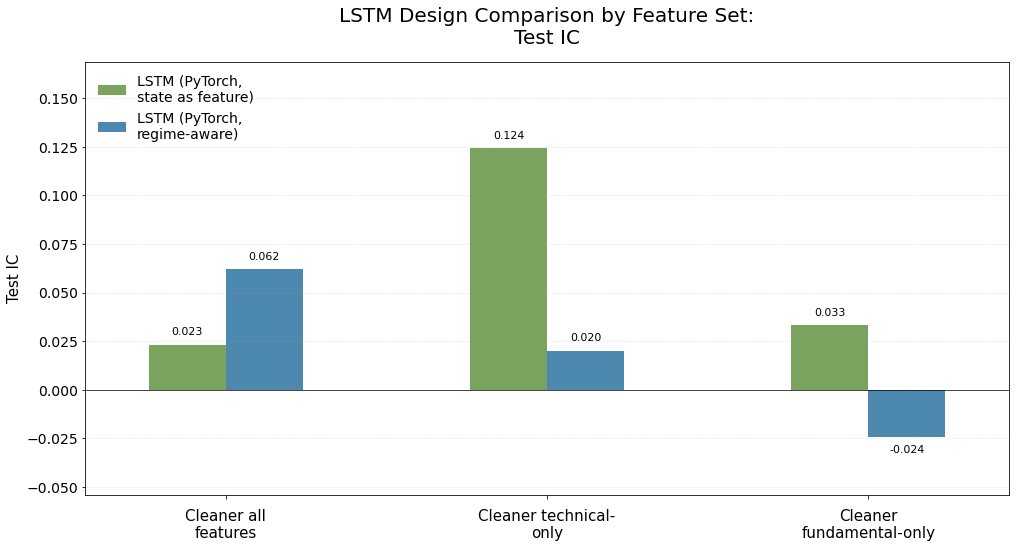

===== Report chart: LSTM design comparison Test R2_oos =====


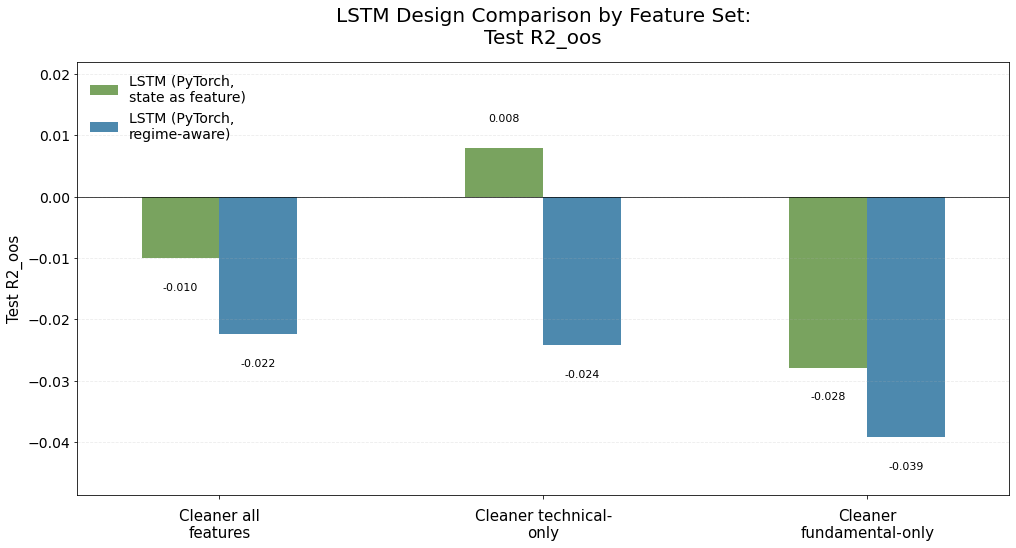


===== Regime-aware model family comparison =====
Regime-aware model family comparison table:


,Feature Set,Test MSE,Test RMSE,Test MAE,Test R2,Test R2_oos,Test IC,Model Family
0,Cleaner all features,0.005873,0.076635,0.058586,-0.022624,-0.022321,0.062034,"LSTM (PyTorch, regime-aware)"
1,Cleaner all features,0.006056,0.077819,0.060855,-0.054458,-0.054131,0.023401,LightGBM (regime-aware)
2,Cleaner all features,0.005873,0.076634,0.059369,-0.022607,-0.022290,0.040846,XGBoost (regime-aware)
3,Cleaner fundamental-only,0.005970,0.077265,0.059175,-0.039514,-0.039206,-0.024467,"LSTM (PyTorch, regime-aware)"
4,Cleaner fundamental-only,0.005864,0.076577,0.059156,-0.021076,-0.020759,0.087023,LightGBM (regime-aware)
5,Cleaner fundamental-only,0.005583,0.074722,0.057462,0.027799,0.028101,0.121071,XGBoost (regime-aware)
6,Cleaner technical-only,0.005884,0.076707,0.058906,-0.024538,-0.024234,0.020029,"LSTM (PyTorch, regime-aware)"
7,Cleaner technical-only,0.006213,0.078820,0.060430,-0.081764,-0.081429,0.064269,LightGBM (regime-aware)
8,Cleaner technical-only,0.006072,0.077922,0.059572,-0.057271,-0.056943,0.042211,XGBoost (regime-aware)


===== Regime-aware model family: Test IC =====


Model Family,"LSTM (PyTorch, regime-aware)",LightGBM (regime-aware),XGBoost (regime-aware)
Feature Set,,,
Cleaner all features,0.062034,0.023401,0.040846
Cleaner fundamental-only,-0.024467,0.087023,0.121071
Cleaner technical-only,0.020029,0.064269,0.042211


===== Regime-aware model family: Test R2_oos =====


Model Family,"LSTM (PyTorch, regime-aware)",LightGBM (regime-aware),XGBoost (regime-aware)
Feature Set,,,
Cleaner all features,-0.022321,-0.054131,-0.022290
Cleaner fundamental-only,-0.039206,-0.020759,0.028101
Cleaner technical-only,-0.024234,-0.081429,-0.056943


===== Report chart: regime-aware model family comparison Test IC =====


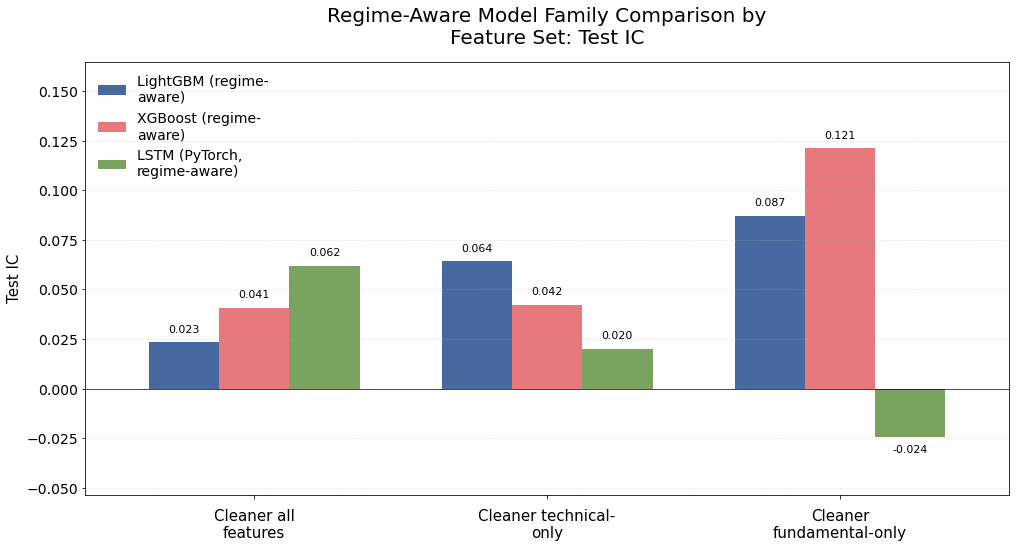

===== Report chart: regime-aware model family comparison Test R2_oos =====


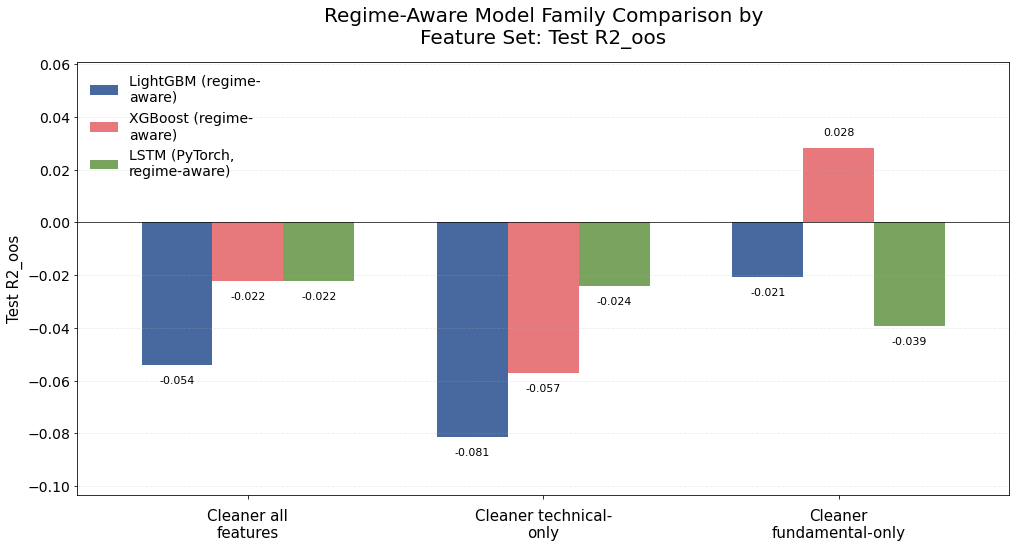

In [25]:
# ===== LSTM regime-aware extension =====
def build_lstm_sequence_dataset_regime_aware(train_panel, test_panel, raw_feature_cols, lookback=LSTM_LOOKBACK):
    cs_feature_cols = map_raw_to_cs_features(raw_feature_cols)
    seq_feature_cols = list(cs_feature_cols)
    combined = pd.concat([train_panel.assign(sample_split='train'), test_panel.assign(sample_split='test')], ignore_index=True)
    combined['Date'] = pd.to_datetime(combined['Date'])
    combined = combined.sort_values(['ticker', 'Date']).reset_index(drop=True)

    X_train_seq, y_train_seq, train_meta = [], [], []
    X_test_seq, y_test_seq, test_meta = [], [], []

    for ticker_value, ticker_df in combined.groupby('ticker'):
        ticker_df = ticker_df.sort_values('Date').reset_index(drop=True)
        feature_array = ticker_df[seq_feature_cols].astype(float).to_numpy()
        target_array = ticker_df['future_return_1m'].astype(float).to_numpy()
        split_array = ticker_df['sample_split'].to_numpy()
        date_array = pd.to_datetime(ticker_df['Date']).to_numpy()
        state_array = ticker_df['state'].to_numpy()

        for end_idx in range(lookback - 1, len(ticker_df)):
            sequence = feature_array[end_idx - lookback + 1:end_idx + 1]
            target = target_array[end_idx]
            if np.isnan(sequence).any() or np.isnan(target):
                continue
            meta_row = {
                'ticker': ticker_value,
                'Date': pd.Timestamp(date_array[end_idx]),
                'state': int(state_array[end_idx])
            }
            if split_array[end_idx] == 'train':
                X_train_seq.append(sequence); y_train_seq.append(target); train_meta.append(meta_row)
            else:
                X_test_seq.append(sequence); y_test_seq.append(target); test_meta.append(meta_row)

    if len(X_train_seq) == 0 or len(X_test_seq) == 0:
        raise ValueError('No valid regime-aware LSTM sequences were created.')

    X_train_seq = np.asarray(X_train_seq, dtype=np.float32)
    y_train_seq = np.asarray(y_train_seq, dtype=np.float32)
    X_test_seq = np.asarray(X_test_seq, dtype=np.float32)
    y_test_seq = np.asarray(y_test_seq, dtype=np.float32)
    train_meta = pd.DataFrame(train_meta).sort_values('Date').reset_index(drop=True)
    test_meta = pd.DataFrame(test_meta).sort_values('Date').reset_index(drop=True)

    train_order = train_meta.index.to_numpy()
    test_order = test_meta.index.to_numpy()
    X_train_seq = X_train_seq[train_order]; y_train_seq = y_train_seq[train_order]
    X_test_seq = X_test_seq[test_order]; y_test_seq = y_test_seq[test_order]

    scaler = StandardScaler()
    scaler.fit(X_train_seq.reshape(-1, X_train_seq.shape[-1]))
    X_train_seq = scaler.transform(X_train_seq.reshape(-1, X_train_seq.shape[-1])).reshape(X_train_seq.shape)
    X_test_seq = scaler.transform(X_test_seq.reshape(-1, X_test_seq.shape[-1])).reshape(X_test_seq.shape)
    return X_train_seq, y_train_seq, X_test_seq, y_test_seq, train_meta, test_meta

def fit_predict_regime_aware_lstm_sequences(
    X_train, y_train, train_meta, X_test, test_meta,
    max_epochs=LSTM_MAX_EPOCHS, patience=LSTM_PATIENCE, min_state_train_size=48
):
    fallback_pred, _, fallback_epochs = fit_predict_lstm_sequences(
        X_train, y_train, X_test, max_epochs=max_epochs, patience=patience
    )
    predictions = fallback_pred.copy()
    state_rows = []
    state_epoch_summary = {}

    for state_value in sorted(train_meta['state'].dropna().unique()):
        train_mask = train_meta['state'].to_numpy() == state_value
        test_mask = test_meta['state'].to_numpy() == state_value
        train_count = int(train_mask.sum())
        test_count = int(test_mask.sum())

        if test_count == 0:
            continue
        if train_count < min_state_train_size:
            state_rows.append({
                'state': int(state_value),
                'train_sequences': train_count,
                'test_sequences': test_count,
                'used_fallback': True,
                'epochs_trained': fallback_epochs
            })
            continue

        state_pred, _, state_epochs = fit_predict_lstm_sequences(
            X_train[train_mask], y_train[train_mask], X_test[test_mask],
            max_epochs=max_epochs, patience=patience
        )
        predictions[test_mask] = state_pred
        state_epoch_summary[int(state_value)] = state_epochs
        state_rows.append({
            'state': int(state_value),
            'train_sequences': train_count,
            'test_sequences': test_count,
            'used_fallback': False,
            'epochs_trained': state_epochs
        })

    state_summary = pd.DataFrame(state_rows)
    return predictions, fallback_epochs, state_summary, state_epoch_summary

def run_lstm_regime_aware_comparison(train_panel, test_panel, raw_feature_cols, label, lookback=LSTM_LOOKBACK):
    X_train_seq, y_train_seq, X_test_seq, y_test_seq, train_meta_seq, test_meta_seq = build_lstm_sequence_dataset_regime_aware(
        train_panel, test_panel, raw_feature_cols, lookback=lookback
    )
    regime_pred, fallback_epochs, state_summary, state_epochs = fit_predict_regime_aware_lstm_sequences(
        X_train_seq, y_train_seq, train_meta_seq, X_test_seq, test_meta_seq,
        max_epochs=LSTM_MAX_EPOCHS, patience=LSTM_PATIENCE
    )
    metrics = evaluate_regression_metrics_monthly(y_test_seq, regime_pred, benchmark_mean=y_train_seq.mean())
    result_row = {
        'Model Family': 'LSTM (PyTorch, regime-aware)',
        'Model Design': 'LSTM (PyTorch, regime-aware)',
        'Feature Set': label,
        'Test MSE': metrics['mse'],
        'Test RMSE': metrics['rmse'],
        'Test MAE': metrics['mae'],
        'Test R2': metrics['r2'],
        'Test R2_oos': metrics['r2_oos'],
        'Test IC': metrics['ic']
    }
    artifacts = {
        'X_train_seq': X_train_seq,
        'y_train_seq': y_train_seq,
        'X_test_seq': X_test_seq,
        'y_test_seq': y_test_seq,
        'train_meta_seq': train_meta_seq,
        'test_meta_seq': test_meta_seq,
        'predictions': regime_pred,
        'fallback_epochs': fallback_epochs,
        'state_summary': state_summary,
        'state_epochs': state_epochs
    }
    return result_row, artifacts

print('===== LSTM design comparison: state as feature vs regime-aware =====')
lstm_state_reference = model_family_comparison[
    model_family_comparison['Model Family'] == 'LSTM (PyTorch)'
][['Feature Set', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', 'Test R2_oos', 'Test IC']].copy()
lstm_state_reference['Model Design'] = 'LSTM (PyTorch, state as feature)'

lstm_regime_aware_rows = []
lstm_regime_aware_store = {}
for feature_set_label, raw_cols in feature_set_configs.items():
    print(f'\n----- {feature_set_label}: regime-aware LSTM -----')
    try:
        lstm_regime_row, lstm_regime_artifacts = run_lstm_regime_aware_comparison(
            monthly_clean_train_cs, monthly_clean_test_cs, raw_cols, feature_set_label, lookback=LSTM_LOOKBACK
        )
        lstm_regime_aware_rows.append(lstm_regime_row)
        lstm_regime_aware_store[feature_set_label] = lstm_regime_artifacts
        print(
            f"Regime-aware LSTM Test IC = {lstm_regime_row['Test IC']:.4f}, "
            f"Test R2_oos = {lstm_regime_row['Test R2_oos']:.4f}"
        )
        display(lstm_regime_artifacts['state_summary'])
    except Exception as lstm_regime_error:
        print(f'Regime-aware LSTM failed for {feature_set_label}: {lstm_regime_error}')

lstm_regime_aware_results = pd.DataFrame(lstm_regime_aware_rows)
lstm_design_comparison = pd.concat([
    lstm_state_reference,
    lstm_regime_aware_results[['Feature Set', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', 'Test R2_oos', 'Test IC', 'Model Design']]
], ignore_index=True).sort_values(['Feature Set', 'Model Design']).reset_index(drop=True)
print('\nLSTM design comparison table:')
display(lstm_design_comparison)

lstm_design_palette = {
    'LSTM (PyTorch, state as feature)': '#6a994e',
    'LSTM (PyTorch, regime-aware)': '#3a7ca5'
}
print('===== Report chart: LSTM design comparison Test IC =====')
plot_grouped_metric_bars(
    lstm_design_comparison.rename(columns={'Model Design': 'Model Family'}),
    'Test IC',
    'LSTM Design Comparison by Feature Set: Test IC',
    'Test IC',
    ['LSTM (PyTorch, state as feature)', 'LSTM (PyTorch, regime-aware)'],
    lstm_design_palette
)
print('===== Report chart: LSTM design comparison Test R2_oos =====')
plot_grouped_metric_bars(
    lstm_design_comparison.rename(columns={'Model Design': 'Model Family'}),
    'Test R2_oos',
    'LSTM Design Comparison by Feature Set: Test R2_oos',
    'Test R2_oos',
    ['LSTM (PyTorch, state as feature)', 'LSTM (PyTorch, regime-aware)'],
    lstm_design_palette
)

print('\n===== Regime-aware model family comparison =====')
lightgbm_regime_aware_reference = cleaner_feature_set_comparison[
    cleaner_feature_set_comparison['Model'] == 'Monthly LightGBM (regime-aware)'
][['Feature Set', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', 'Test R2_oos', 'Test IC']].copy()
lightgbm_regime_aware_reference['Model Family'] = 'LightGBM (regime-aware)'

xgboost_regime_aware_reference = xgboost_design_comparison[
    xgboost_design_comparison['Model Design'] == 'XGBoost (regime-aware)'
][['Feature Set', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', 'Test R2_oos', 'Test IC']].copy()
xgboost_regime_aware_reference['Model Family'] = 'XGBoost (regime-aware)'

lstm_regime_aware_reference = lstm_regime_aware_results[[
    'Feature Set', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', 'Test R2_oos', 'Test IC'
].copy()]
lstm_regime_aware_reference['Model Family'] = 'LSTM (PyTorch, regime-aware)'

regime_aware_model_family_comparison = pd.concat([
    lightgbm_regime_aware_reference,
    xgboost_regime_aware_reference,
    lstm_regime_aware_reference
], ignore_index=True).sort_values(['Feature Set', 'Model Family']).reset_index(drop=True)
print('Regime-aware model family comparison table:')
display(regime_aware_model_family_comparison)

regime_aware_model_family_test_ic = regime_aware_model_family_comparison.pivot(
    index='Feature Set', columns='Model Family', values='Test IC'
 )
print('===== Regime-aware model family: Test IC =====')
display(regime_aware_model_family_test_ic)

regime_aware_model_family_test_r2_oos = regime_aware_model_family_comparison.pivot(
    index='Feature Set', columns='Model Family', values='Test R2_oos'
 )
print('===== Regime-aware model family: Test R2_oos =====')
display(regime_aware_model_family_test_r2_oos)

regime_aware_family_order = [
    'LightGBM (regime-aware)',
    'XGBoost (regime-aware)',
    'LSTM (PyTorch, regime-aware)'
]
regime_aware_family_palette = {
    'LightGBM (regime-aware)': '#345995',
    'XGBoost (regime-aware)': '#e56b6f',
    'LSTM (PyTorch, regime-aware)': '#6a994e'
}
print('===== Report chart: regime-aware model family comparison Test IC =====')
plot_grouped_metric_bars(
    regime_aware_model_family_comparison,
    'Test IC',
    'Regime-Aware Model Family Comparison by Feature Set: Test IC',
    'Test IC',
    regime_aware_family_order,
    regime_aware_family_palette
)
print('===== Report chart: regime-aware model family comparison Test R2_oos =====')
plot_grouped_metric_bars(
    regime_aware_model_family_comparison,
    'Test R2_oos',
    'Regime-Aware Model Family Comparison by Feature Set: Test R2_oos',
    'Test R2_oos',
    regime_aware_family_order,
    regime_aware_family_palette
)

# 8. Model Diagnostics & Feature Importance

Diagnostics for the best cleaner fundamental-only model (state-as-feature and regime-aware), including scatter plots, time-series overlays, by-state metrics, and feature importance.

===== Interpretation of the best cleaner model =====


,metric,value
0,Test R2_oos,0.016734
1,Test IC,0.108331
2,Test MSE,0.005649
3,Benchmark mean forecast,0.013855


===== Feature importance: cleaner fundamental-only with state as feature =====


,feature,importance,importance_pct,Model,Feature Set
0,gross_margin_cs_q,1376,0.152889,Cleaner fundamental-only (state as feature),Cleaner fundamental-only
1,ebitda_margin_cs_q,1354,0.150444,Cleaner fundamental-only (state as feature),Cleaner fundamental-only
2,pfcf_ratio_cs_q,1329,0.147667,Cleaner fundamental-only (state as feature),Cleaner fundamental-only
3,debt_to_equity_cs_q,1276,0.141778,Cleaner fundamental-only (state as feature),Cleaner fundamental-only
4,cash_to_liabilities_cs_q,1257,0.139667,Cleaner fundamental-only (state as feature),Cleaner fundamental-only
5,return_on_assets_cs_q,1207,0.134111,Cleaner fundamental-only (state as feature),Cleaner fundamental-only
6,quick_ratio_cs_q,1031,0.114556,Cleaner fundamental-only (state as feature),Cleaner fundamental-only
7,state,170,0.018889,Cleaner fundamental-only (state as feature),Cleaner fundamental-only


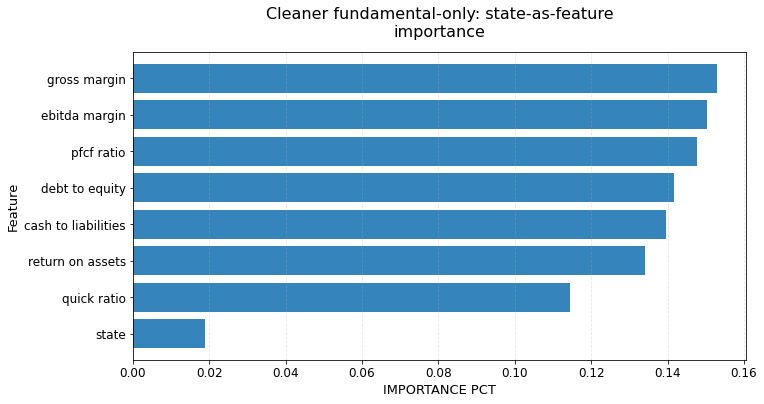

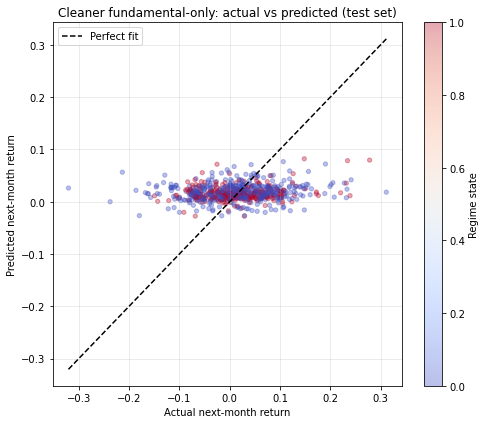

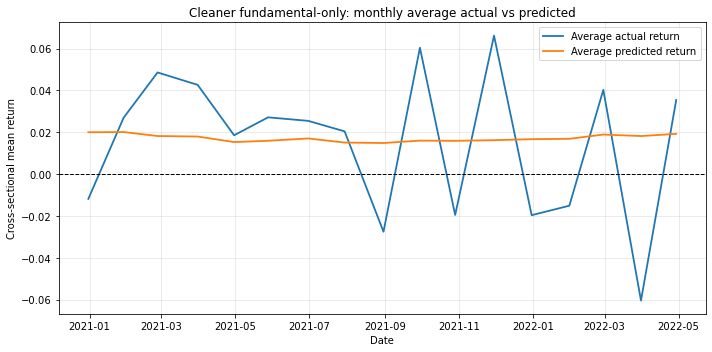

===== Test performance by regime state =====


,state,mse,rmse,mae,r2,r2_oos,ic
0,0,0.006657,0.081590,0.062851,0.004524,0.004843,0.118463
1,1,0.004208,0.064871,0.050655,0.042299,0.042587,0.076188


In [19]:
# ===== Best cleaner model diagnostics =====
best_cleaner_label = 'Cleaner fundamental-only'
best_cleaner_store = cleaner_feature_set_model_store[best_cleaner_label]

best_cleaner_state_model = best_cleaner_store['state_feature_model']
best_cleaner_X_test = best_cleaner_store['X_test_with_state']
best_cleaner_y_test = best_cleaner_store['y_test']
best_cleaner_pred = pd.Series(best_cleaner_store['predictions']['state_as_feature'], index=best_cleaner_X_test.index, name='predicted_return')

best_cleaner_actual_vs_pred = pd.DataFrame({
    'Date': pd.to_datetime(best_cleaner_y_test.index),
    'actual_return': best_cleaner_y_test.values,
    'predicted_return': best_cleaner_pred.values,
    'state': best_cleaner_X_test['state'].values
}).reset_index(drop=True)

best_cleaner_metrics = evaluate_regression_metrics_monthly(
    best_cleaner_actual_vs_pred['actual_return'],
    best_cleaner_actual_vs_pred['predicted_return'],
    benchmark_mean=best_cleaner_store['benchmark_mean']
)

print('===== Interpretation of the best cleaner model =====')
display(pd.DataFrame({
    'metric': ['Test R2_oos', 'Test IC', 'Test MSE', 'Benchmark mean forecast'],
    'value': [best_cleaner_metrics['r2_oos'], best_cleaner_metrics['ic'], best_cleaner_metrics['mse'], best_cleaner_store['benchmark_mean']]
}))

# Feature importance
best_cleaner_importance = extract_feature_importance(
    best_cleaner_state_model, best_cleaner_store['X_train_with_state'].columns,
    model_label='Cleaner fundamental-only (state as feature)', feature_set_label=best_cleaner_label
)
print('===== Feature importance: cleaner fundamental-only with state as feature =====')
display(best_cleaner_importance)
plot_feature_importance_bar(best_cleaner_importance, 'Cleaner fundamental-only: state-as-feature importance', top_n=len(best_cleaner_importance))

# Scatter plot
scatter_min = min(best_cleaner_actual_vs_pred['actual_return'].min(), best_cleaner_actual_vs_pred['predicted_return'].min())
scatter_max = max(best_cleaner_actual_vs_pred['actual_return'].max(), best_cleaner_actual_vs_pred['predicted_return'].max())

plt.figure(figsize=(7, 6))
plt.scatter(best_cleaner_actual_vs_pred['actual_return'], best_cleaner_actual_vs_pred['predicted_return'],
            alpha=0.35, s=18, c=best_cleaner_actual_vs_pred['state'], cmap='coolwarm')
plt.plot([scatter_min, scatter_max], [scatter_min, scatter_max], color='black', linestyle='--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual next-month return'); plt.ylabel('Predicted next-month return')
plt.title('Cleaner fundamental-only: actual vs predicted (test set)')
plt.colorbar(label='Regime state'); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Time series overlay
best_cleaner_ts = best_cleaner_actual_vs_pred.groupby('Date', as_index=False)[['actual_return', 'predicted_return']].mean()
plt.figure(figsize=(10, 5))
plt.plot(best_cleaner_ts['Date'], best_cleaner_ts['actual_return'], label='Average actual return', linewidth=1.8)
plt.plot(best_cleaner_ts['Date'], best_cleaner_ts['predicted_return'], label='Average predicted return', linewidth=1.8)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Cleaner fundamental-only: monthly average actual vs predicted')
plt.xlabel('Date'); plt.ylabel('Cross-sectional mean return'); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# By-state performance
best_cleaner_by_state = best_cleaner_actual_vs_pred.groupby('state').apply(
    lambda df: pd.Series(evaluate_regression_metrics_monthly(df['actual_return'], df['predicted_return'], benchmark_mean=best_cleaner_store['benchmark_mean'])),
    include_groups=False
).reset_index()
print('===== Test performance by regime state =====')
display(best_cleaner_by_state)

===== Regime-aware test performance by state =====


,state,mse,rmse,mae,r2,r2_oos,ic
0,0,0.007054,0.083988,0.065387,-0.054861,-0.054523,0.056176
1,1,0.004164,0.064529,0.050253,0.052362,0.052647,0.149165


===== By-state feature importance comparison =====


,state_0_importance_pct,state_1_importance_pct
feature_clean,,
gross_margin,0.183667,0.168889
ebitda_margin,0.172333,0.148667
pfcf_ratio,0.168667,0.152667
return_on_assets,0.150333,0.123778
debt_to_equity,0.126222,0.133667
cash_to_liabilities,0.104667,0.142889
quick_ratio,0.094111,0.129444


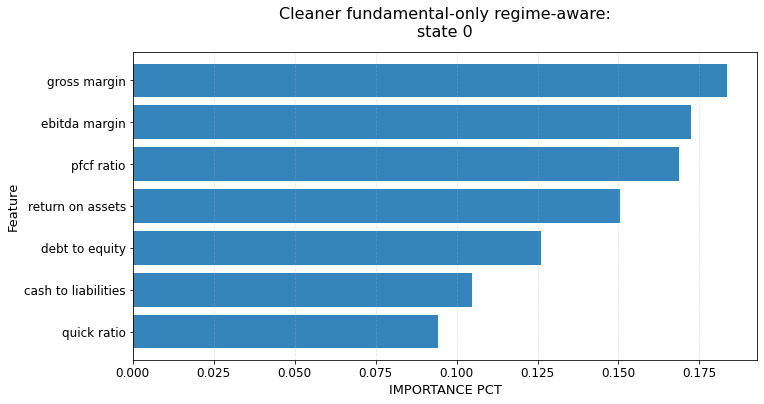

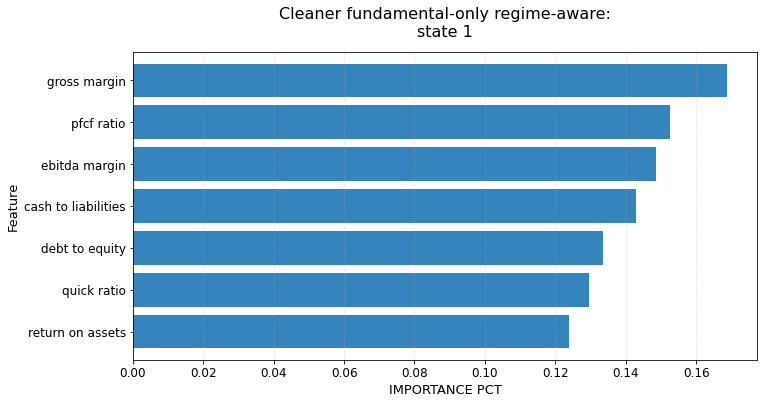

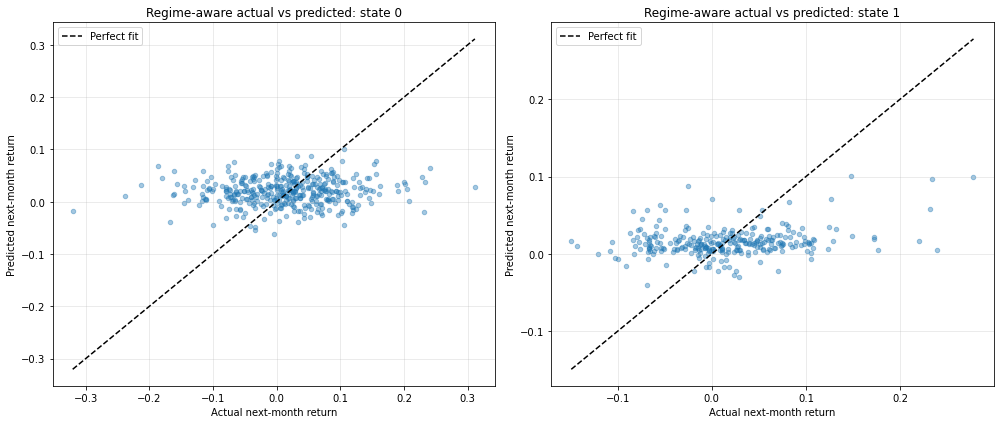

In [20]:
# ===== Cleaner fundamental-only regime-aware diagnostics =====
cleaner_regime_store = cleaner_feature_set_model_store[best_cleaner_label]
cleaner_regime_bundle = cleaner_regime_store['regime_bundle']
cleaner_regime_X_train = cleaner_regime_store['X_train_with_state']
cleaner_regime_X_test = cleaner_regime_store['X_test_with_state']
cleaner_regime_y_test = cleaner_regime_store['y_test']
cleaner_regime_pred = pd.Series(cleaner_regime_store['predictions']['regime_aware'], index=cleaner_regime_X_test.index, name='predicted_return')

cleaner_regime_actual_vs_pred = pd.DataFrame({
    'Date': pd.to_datetime(cleaner_regime_y_test.index),
    'actual_return': cleaner_regime_y_test.values,
    'predicted_return': cleaner_regime_pred.values,
    'state': cleaner_regime_X_test['state'].values
}).reset_index(drop=True)

cleaner_regime_by_state_metrics = cleaner_regime_actual_vs_pred.groupby('state').apply(
    lambda df: pd.Series(evaluate_regression_metrics_monthly(df['actual_return'], df['predicted_return'], benchmark_mean=cleaner_regime_store['benchmark_mean'])),
    include_groups=False
).reset_index()
print('===== Regime-aware test performance by state =====')
display(cleaner_regime_by_state_metrics)

# By-state feature importance
cleaner_regime_state_importance, cleaner_regime_weighted_importance = summarize_regime_aware_importance(
    cleaner_regime_bundle, cleaner_regime_X_train, feature_set_label=best_cleaner_label
)
cleaner_regime_state_importance['feature_clean'] = cleaner_regime_state_importance['feature'].str.replace('_cs_q', '', regex=False)
cleaner_regime_weighted_importance['feature_clean'] = cleaner_regime_weighted_importance['feature'].str.replace('_cs_q', '', regex=False)

cleaner_regime_importance_pivot = cleaner_regime_state_importance.pivot_table(
    index='feature_clean', columns='state', values='importance_pct', aggfunc='first'
).fillna(0)
cleaner_regime_importance_pivot.columns = [f'state_{int(col)}_importance_pct' for col in cleaner_regime_importance_pivot.columns]
cleaner_regime_importance_pivot = cleaner_regime_importance_pivot.sort_values(by=list(cleaner_regime_importance_pivot.columns), ascending=False)
print('===== By-state feature importance comparison =====')
display(cleaner_regime_importance_pivot)

for state_value in sorted(cleaner_regime_state_importance['state'].unique()):
    state_imp = cleaner_regime_state_importance[cleaner_regime_state_importance['state'] == state_value][['feature_clean', 'importance_pct']].rename(columns={'feature_clean': 'feature'})
    plot_feature_importance_bar(state_imp, f'Cleaner fundamental-only regime-aware: state {state_value}', value_col='importance_pct', top_n=len(state_imp))

# Scatter by state
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)
for axis_idx, state_value in enumerate(sorted(cleaner_regime_actual_vs_pred['state'].unique())):
    state_df = cleaner_regime_actual_vs_pred[cleaner_regime_actual_vs_pred['state'] == state_value]
    s_min = min(state_df['actual_return'].min(), state_df['predicted_return'].min())
    s_max = max(state_df['actual_return'].max(), state_df['predicted_return'].max())
    axes[axis_idx].scatter(state_df['actual_return'], state_df['predicted_return'], alpha=0.4, s=20, color='tab:blue')
    axes[axis_idx].plot([s_min, s_max], [s_min, s_max], linestyle='--', linewidth=1.5, color='black', label='Perfect fit')
    axes[axis_idx].set_title(f'Regime-aware actual vs predicted: state {state_value}')
    axes[axis_idx].set_xlabel('Actual next-month return'); axes[axis_idx].set_ylabel('Predicted next-month return')
    axes[axis_idx].legend(); axes[axis_idx].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 9. Fama-MacBeth Extension (Optional)

Cleaner fundamental-only Fama-MacBeth with regime interactions. This provides an econometric cross-check on whether regime interactions in cleaner fundamentals are statistically significant and interpretable.

In [21]:
cleaner_fundamental_cs_cols = map_raw_to_cs_features(cleaner_fundamental_cols)

monthly_clean_full_cs = pd.concat([monthly_clean_train_cs, monthly_clean_test_cs], ignore_index=True)
monthly_clean_full_cs = monthly_clean_full_cs.sort_values(['Date', 'ticker']).reset_index(drop=True)

cleaner_fundamental_fm_panel = monthly_clean_full_cs[[
    'Date', 'ticker', 'state', 'future_return_1m', *cleaner_fundamental_cs_cols
]].dropna().copy()
cleaner_fundamental_fm_panel['state_indicator'] = (cleaner_fundamental_fm_panel['state'] == 1).astype(int)

cleaner_fundamental_interaction_cols = []
for col in cleaner_fundamental_cs_cols:
    interaction_col = f'{col}_x_state1'
    cleaner_fundamental_fm_panel[interaction_col] = cleaner_fundamental_fm_panel[col] * cleaner_fundamental_fm_panel['state_indicator']
    cleaner_fundamental_interaction_cols.append(interaction_col)

cleaner_fundamental_fm_feature_cols = cleaner_fundamental_cs_cols + ['state_indicator'] + cleaner_fundamental_interaction_cols
cleaner_fm_summary, cleaner_fm_betas = run_fama_macbeth(
    cleaner_fundamental_fm_panel, cleaner_fundamental_fm_feature_cols, target_col='future_return_1m', min_obs=25
)

cleaner_fm_interactions_only = cleaner_fm_summary.loc[['state_indicator'] + cleaner_fundamental_interaction_cols].copy()
cleaner_fm_interactions_only['term_type'] = ['state_level_shift'] + ['factor_x_regime1'] * len(cleaner_fundamental_interaction_cols)
cleaner_fm_interactions_only['feature'] = ['state_indicator'] + cleaner_fundamental_cols
cleaner_fm_interactions_only = cleaner_fm_interactions_only.sort_values('abs_t', ascending=False)

cleaner_fm_main_effects = cleaner_fm_summary.loc[cleaner_fundamental_cs_cols].copy()
cleaner_fm_main_effects['feature'] = cleaner_fundamental_cols
cleaner_fm_main_effects = cleaner_fm_main_effects.sort_values('abs_t', ascending=False)

print('===== Cleaner fundamental-only Fama-MacBeth with regime interactions =====')
print('Each *_x_state1 coefficient measures how the slope in regime 1 differs from regime 0.')
display(cleaner_fm_interactions_only[['feature', 'term_type', 'mean_beta', 't_stat', 'p_value', 'abs_t']])

print('===== Main effects (regime 0 baseline slopes) =====')
display(cleaner_fm_main_effects[['feature', 'mean_beta', 't_stat', 'p_value', 'abs_t']])

===== Cleaner fundamental-only Fama-MacBeth with regime interactions =====
Each *_x_state1 coefficient measures how the slope in regime 1 differs from regime 0.


,feature,term_type,mean_beta,t_stat,p_value,abs_t
state_indicator,state_indicator,state_level_shift,0.005268,4.768685,0.000005,4.768685
cash_to_liabilities_cs_q_x_state1,cash_to_liabilities,factor_x_regime1,0.002518,2.534434,0.012529,2.534434
quick_ratio_cs_q_x_state1,quick_ratio,factor_x_regime1,-0.001129,-1.363192,0.175333,1.363192
return_on_assets_cs_q_x_state1,return_on_assets,factor_x_regime1,-0.000565,-0.710487,0.478758,0.710487
gross_margin_cs_q_x_state1,gross_margin,factor_x_regime1,-0.000554,-0.580785,0.562457,0.580785
ebitda_margin_cs_q_x_state1,ebitda_margin,factor_x_regime1,0.000394,0.475352,0.635386,0.475352
debt_to_equity_cs_q_x_state1,debt_to_equity,factor_x_regime1,-0.000154,-0.317086,0.751720,0.317086
pfcf_ratio_cs_q_x_state1,pfcf_ratio,factor_x_regime1,0.000094,0.141233,0.887919,0.141233


===== Main effects (regime 0 baseline slopes) =====


,feature,mean_beta,t_stat,p_value,abs_t
debt_to_equity_cs_q,debt_to_equity,-0.002465,-2.900635,0.004419,2.900635
pfcf_ratio_cs_q,pfcf_ratio,-0.002219,-1.953138,0.053093,1.953138
quick_ratio_cs_q,quick_ratio,-0.001772,-1.236997,0.218464,1.236997
return_on_assets_cs_q,return_on_assets,-0.001549,-1.035403,0.302529,1.035403
cash_to_liabilities_cs_q,cash_to_liabilities,0.001329,0.806942,0.421271,0.806942
gross_margin_cs_q,gross_margin,0.001126,0.677803,0.499180,0.677803
ebitda_margin_cs_q,ebitda_margin,-0.000256,-0.201715,0.840475,0.201715


# 10. Conclusion

## Key Findings

This project examines whether the predictive power of stock-level signals changes across market regimes, with the main emphasis on machine-learning models. The final evidence does not support a single universally best model across all feature families. Instead, the results point to a **model-by-feature-family pattern**.

## Route 1: Technical-Signal Route

The preferred technical-signal route is the **Cleaner technical-only PyTorch LSTM**. Its advantage is strongest in cross-sectional ranking, where it delivers the highest Test IC among the technical-only specifications and remains ahead of both LightGBM and XGBoost on the same cleaned feature set. The subsequent tuning exercise did not improve the final test result, suggesting the original specification was already near an effective operating point.

## Route 2: Fundamental-Signal Route

The preferred fundamental-signal route is the **Cleaner fundamental-only regime-aware XGBoost** model. This specification improves on the corresponding state-as-feature design and surpasses the cleaner fundamental-only LightGBM benchmark in predictive performance. Fundamental information benefits more from regime-conditional modeling than from simply appending the market state as an extra predictor.

## Report-Level Message

The project supports a comparative and conditional view of predictive power:

- **Technical indicators** are most useful when the task is short-run cross-sectional ranking and timing; their strongest implementation is sequence-based learning through a technical-only PyTorch LSTM.
- **Cleaner fundamental signals** become most effective when the model is explicitly allowed to vary across market states; their strongest implementation is the cleaner fundamental-only regime-aware XGBoost.

This split outcome shows that regime dependence interacts with the type of information being modeled and with the architecture used to model it. The Fama-MacBeth results further support this interpretation by showing that regime shifts matter statistically and the cleaner fundamental specification produces concentrated, interpretable regime-dependent effects.